# Projet final DataBird — Garanteo

**Mission** : à l'approche de la révision budgétaire de fin de trimestre, Garanteo cherche à affiner sa stratégie d'acquisition digitale pour renforcer sa position sur son marché.

**Problématique** : quel est le coût d'acquisition réel de chacune des 13 campagnes, et quelles campagnes faut-il renforcer ou couper avant la révision budgétaire ?

**Sous-problématiques**
1. Une fois les données dédoublonnées et jointes, quel est le coût d'acquisition réel de chaque campagne (et non les chiffres bruts faussés par les doublons) ?
2. Le classement des campagnes change-t-il selon la règle d'attribution retenue ? Laquelle recommander à Garanteo ?
3. Le pitch téléphonique améliore-t-il réellement la conversion, ou est-ce une fausse bonne pratique à corriger ?

**Auteur** : Sophie Paradon · **Track** : DAFT · **Restitution** : 31/08/2026

Le notebook se lit de haut en bas dans l'ordre imposé par la consigne : Importation → Exploration primaire → Nettoyage → Transformation → Analyse statistiques.

# 0. Importation des packages et du ou des jeux de données

## Importation des packages pour analyses

### Nous aurons besoin de...

Tous les imports du notebook sont regroupés ici, une seule fois, pour qu'on voie d'un coup d'œil de quoi dépend l'analyse.

| Package | À quoi il sert ici |
|---|---|
| `pandas` | charger les CSV, nettoyer, joindre, agréger |
| `numpy` | remplacer les infinis, calculs de bornes |
| `matplotlib` / `seaborn` | boxplot, histogramme, graphiques |
| `scipy.stats` | tests statistiques (khi-deux, test t, Fisher, corrélations) |
| `os` | gérer les chemins de fichiers et créer le dossier de sortie |

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Affichage : on veut voir toutes les colonnes des tableaux, sans troncature au milieu
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

pandas 2.2.3 | numpy 2.1.3 | seaborn 0.13.2


→ Les 6 packages sont chargés. Rien d'autre ne sera importé plus loin dans le notebook : tout ce dont l'analyse a besoin est déclaré ici.

## Importation du ou des jeux de données

### Où sont les fichiers

**L'environnement de référence est Google Colab** : les 4 tables brutes fournies par Garanteo sont déposées sur le Drive, dans `MyDrive/Databird/Projet Final GARANTEO/`, et c'est là que tourne l'intégralité de l'analyse. Les tables nettoyées sont écrites dans le sous-dossier `propre/` du même dossier Drive, puis récupérées en local pour alimenter le dashboard Power BI.

Le bloc ci-dessous détecte quand même l'environnement au lieu de coder un seul chemin en dur : si le notebook est ouvert ailleurs que dans Colab, il retombe sur l'arborescence du dossier projet et continue de s'exécuter. C'est ce que demande la consigne « aucune cellule ne doit renvoyer une erreur ».

In [2]:
if os.path.exists("/content"):
    # Environnement de référence : Google Colab, données sur le Drive
    from google.colab import drive
    drive.mount("/content/drive")
    ENVIRONNEMENT = "Google Colab (Drive)"
    RACINE = "/content/drive/MyDrive/Databird/Projet Final GARANTEO"
    DOSSIER_BRUT = RACINE            # les 4 CSV d'origine
    DOSSIER_PROPRE = f"{RACINE}/propre"   # les tables nettoyées
else:
    # Repli hors Colab : mêmes tables, arborescence du dossier projet
    ENVIRONNEMENT = "local (dossier projet)"
    DOSSIER_BRUT = "../01_Donnees/brut"
    DOSSIER_PROPRE = "../01_Donnees/propre"

os.makedirs(DOSSIER_PROPRE, exist_ok=True)
print("Environnement   :", ENVIRONNEMENT)
print("Données brutes  :", DOSSIER_BRUT)
print("Données propres :", DOSSIER_PROPRE)

Mounted at /content/drive
Environnement   : Google Colab (Drive)
Données brutes  : /content/drive/MyDrive/Databird/Projet Final GARANTEO
Données propres : /content/drive/MyDrive/Databird/Projet Final GARANTEO/propre


→ Les chemins sont résolus. `DOSSIER_BRUT` contient les 4 CSV d'origine, jamais modifiés ; `DOSSIER_PROPRE` recevra les fichiers nettoyés et les tables d'export du dashboard. Toute la suite du notebook passe par ces deux variables : aucun chemin n'est réécrit en dur plus loin.

### Chargement des 4 tables

Les 4 fichiers fournis par Garanteo, chargés avec `read_csv` :

| Table | Contenu |
|---|---|
| `prospects` | les personnes qui ont cliqué sur un CTC et rempli un formulaire de rappel |
| `sessions` | les sessions de navigation enregistrées par Google Analytics |
| `events` | les clics et conversions sur le site web |
| `campaigns` | les campagnes d'acquisition payante (Google Ads et affiliation) |

In [3]:
prospects = pd.read_csv(f"{DOSSIER_BRUT}/prospects.csv")
sessions = pd.read_csv(f"{DOSSIER_BRUT}/sessions.csv")
events = pd.read_csv(f"{DOSSIER_BRUT}/events.csv")
campaigns = pd.read_csv(f"{DOSSIER_BRUT}/campaigns.csv")

for nom, table in [("prospects", prospects), ("sessions", sessions),
                   ("events", events), ("campaigns", campaigns)]:
    print(f"{nom:11s} {table.shape[0]:>7d} lignes x {table.shape[1]:>2d} colonnes")

prospects      2160 lignes x  8 colonnes
sessions      23823 lignes x 10 colonnes
events       101450 lignes x 15 colonnes
campaigns        13 lignes x  6 colonnes


→ Les 4 tables sont chargées : 2 160 prospects, 23 823 sessions, 101 450 events, 13 campagnes.

La consigne impose un minimum de 50 000 points de données. `events` seule en fournit 101 450 × 15 ≈ **1,52 million**, et les 4 tables réunies **1 777 338**. Le seuil est très largement dépassé.

In [4]:
volumetrie = pd.DataFrame(
    [{"table": nom, "lignes": t.shape[0], "colonnes": t.shape[1],
      "points_de_donnees": t.shape[0] * t.shape[1]}
     for nom, t in [("prospects", prospects), ("sessions", sessions),
                    ("events", events), ("campaigns", campaigns)]]
)
volumetrie.loc[len(volumetrie)] = ["TOTAL", volumetrie.lignes.sum(), "-",
                                   volumetrie.points_de_donnees.sum()]
volumetrie

,table,lignes,colonnes,points_de_donnees
0,prospects,2160,8,17280
1,sessions,23823,10,238230
2,events,101450,15,1521750
3,campaigns,13,6,78
4,TOTAL,127446,-,1777338


→ 1 777 338 points de données au total, soit 35 fois le minimum demandé par la consigne. On peut passer à l'exploration.

# 1. Exploration primaire de la donnée des différents jeux

Objectif de cette section : savoir ce qu'on a **avant** de toucher à quoi que ce soit. On regarde la forme (`shape`), les types et les valeurs manquantes (`info`), les ordres de grandeur (`describe`), et les doublons. Aucune ligne n'est modifiée ici : les corrections viennent en section 2.

## Aperçu général du jeu de données **prospects**

In [5]:
prospects.head()

,Unnamed: 0,user_id,prospect_id,prospect_creation_date,is_presented_prospect,is_client,gender,age
0,0,684630696291444,p_96e4f7,2023-08-13,1,0,F,81
1,1,147942796817941,p_8841a5,2023-07-16,1,0,F,60
2,2,124864507964377,p_8970a5,2023-12-16,1,0,M,30
3,3,149579675976397,p_51ef6a,2023-10-31,0,0,M,22
4,4,209311476200613,p_045376,2023-04-04,0,0,M,53


→ Aperçu cohérent avec le dictionnaire de données : `user_id`, `prospect_id`, dates, indicateurs binaires (`is_presented_prospect`, `is_client`), `gender`, `age`. On repère déjà une colonne `Unnamed: 0` qui n'est pas dans la documentation : c'est l'index Pandas d'origine, resté collé à l'export du CSV.

In [6]:
prospects.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Unnamed: 0              2160 non-null   int64 
 1   user_id                 2160 non-null   int64 
 2   prospect_id             2160 non-null   object
 3   prospect_creation_date  2160 non-null   object
 4   is_presented_prospect   2160 non-null   int64 
 5   is_client               2160 non-null   int64 
 6   gender                  2106 non-null   object
 7   age                     2160 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 135.1+ KB


→ 2 160 lignes, 8 colonnes. Seule `gender` a des valeurs manquantes (2 106/2 160 non-null). `prospect_creation_date` est en texte (`object`), pas en date : à convertir avant tout regroupement par mois. Aucune valeur manquante sur `age`.

In [7]:
prospects.describe()

,Unnamed: 0,user_id,is_presented_prospect,is_client,age
count,2160.000000,2.160000e+03,2160.000000,2160.000000,2160.000000
mean,984.129630,3.137725e+14,0.315741,0.087037,51.349537
std,616.344287,2.103371e+14,0.464918,0.281955,14.802812
min,0.000000,1.000035e+14,0.000000,0.000000,21.000000
25%,439.750000,1.724159e+14,0.000000,0.000000,41.000000
50%,979.500000,2.521627e+14,0.000000,0.000000,51.000000
75%,1519.250000,3.282159e+14,1.000000,0.000000,60.000000
max,2059.000000,9.959071e+14,1.000000,1.000000,85.000000


→ `age` va de 21 à 85 ans (moyenne 51,3). `is_presented_prospect` à 31,57 % et `is_client` à 8,70 % : **ces taux vont bouger une fois les doublons supprimés**, ils ne sont donc pas encore exploitables.

In [8]:
prospects.isna().sum()

,0
Unnamed: 0,0
user_id,0
prospect_id,0
prospect_creation_date,0
is_presented_prospect,0
is_client,0
gender,54
age,0


→ Seule `gender` a des trous : 54 valeurs manquantes, à traiter dans le nettoyage.

### Valeurs invalides dans gender

`isna()` ne voit que les cases vides. Une valeur invalide mais présente (une faute de saisie, un code numérique dans une colonne texte) passe au travers. On liste donc les valeurs réellement observées.

In [9]:
prospects["gender"].value_counts(dropna=False)

,count
gender,
F,1264
M,772
123,70
NaN,54


→ **`gender` contient la valeur `123` sur 70 lignes.** Ce n'est pas un genre : c'est une saisie invalide, à recoder en valeur manquante dans le nettoyage. À côté : 1 204 `F`, 739 `M`, 54 vides. C'est le symptôme d'une absence de contrôle à la saisie côté Garanteo, à remonter au client.

### Repérer les doublons de prospect_id

In [10]:
prospects["prospect_id"].duplicated().sum()

np.int64(100)

→ 100 `prospect_id` apparaissent en double sur les 2 160 lignes. À traiter avant tout calcul, sinon tous les indicateurs seront faussés (un client compté deux fois fait baisser artificiellement le coût d'acquisition).

## Aperçu général du jeu de données **sessions**

In [11]:
sessions.head()

,Unnamed: 0,session_id,session_started_at,session_ended_at,user_id,device_type,device_browser,device_operating_system,device_language,country
0,0,NaN,2023-05-22 12:44:38,2023-05-22 13:34:51,271341289732357,mobile,google,ios,FR,NaN
1,1,NaN,2023-03-07 11:53:36,2023-03-07 12:31:12,271341289732357,mobile,google,ios,FR,NaN
2,2,NaN,2023-08-17 19:29:25,2023-08-17 20:06:29,271341289732357,mobile,google,ios,FR,NaN
3,3,NaN,2023-06-15 20:26:28,2023-06-15 21:25:11,271341289732357,mobile,google,ios,FR,NaN
4,4,NaN,2023-01-26 22:09:59,2023-01-26 22:16:11,935605800087124,mobile,google,ios,FR,FR


→ `session_id` est vide dès la première ligne affichée, à confirmer sur l'ensemble du fichier avec `.info()`. `device_browser` affiche « google », qui n'est pas un vrai navigateur, à vérifier juste après. `country` est vide sur certaines lignes alors que `device_language` est rempli.

In [12]:
sessions["device_browser"].unique()

array(['google', nan, 'yahoo', 'bing'], dtype=object)

→ `device_browser` ne contient que des **moteurs de recherche** (google, yahoo, bing) et des `NaN`, jamais de vrai navigateur (Chrome, Safari, Firefox). La colonne est mal nommée à la source : ce n'est pas une poignée de valeurs isolées à corriger, c'est le libellé de la colonne qui est faux.

In [13]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23823 entries, 0 to 23822
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               23823 non-null  int64  
 1   session_id               20514 non-null  float64
 2   session_started_at       23823 non-null  object 
 3   session_ended_at         23823 non-null  object 
 4   user_id                  23823 non-null  int64  
 5   device_type              22677 non-null  object 
 6   device_browser           19047 non-null  object 
 7   device_operating_system  14829 non-null  object 
 8   device_language          14453 non-null  object 
 9   country                  21447 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 1.8+ MB


In [14]:
(sessions.isna().sum() / len(sessions) * 100).round(1)

,0
Unnamed: 0,0.0
session_id,13.9
session_started_at,0.0
session_ended_at,0.0
user_id,0.0
device_type,4.8
device_browser,20.0
device_operating_system,37.8
device_language,39.3
country,10.0


→ `session_id` manquant sur 13,9 % des lignes. `device_operating_system` (37,8 %) et `device_language` (39,3 %) très incomplets. `device_type` (4,8 %), `device_browser` (20 %) et `country` (10 %) ont aussi des trous, dans une moindre mesure.

→ Pas de `.describe()` ici : `sessions` n'a aucune colonne numérique métier, seulement des identifiants (`Unnamed: 0`, `user_id`). Faire la moyenne d'un identifiant ne veut rien dire.

In [15]:
sessions.duplicated().sum()  # lignes strictement identiques sur toutes les colonnes

np.int64(850)

→ 850 lignes strictement identiques dans `sessions`. Suppression simple possible, pas de conflit à arbitrer (contrairement à `prospects`, où les doublons divergent sur l'âge — voir section 2).

## Aperçu général du jeu de données **events**

In [16]:
events.head()

,Unnamed: 0,event_id,session_id,event_timestamp,event_type,url,referrer,medium,campaign_id,user_id,device_type,device_browser,device_operating_system,device_language,country
0,22,NaN,NaN,NaN,click,https://www.site.com/page4,https://www.site.com/page6,internal,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23,NaN,NaN,NaN,click,https://www.site.com/page5,https://www.site.com/page4,internal,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24,NaN,NaN,NaN,click,https://www.site.com/page4,https://www.site.com/page2,internal,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25,NaN,NaN,NaN,click,https://www.site.com/page3,https://www.site.com/page2,internal,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,26,NaN,NaN,NaN,click,https://www.site.com/page1,https://www.site.com/page4,internal,NaN,NaN,NaN,NaN,NaN,NaN,NaN


→ Les 5 premières lignes n'ont que `event_type`, `url`, `referrer` et `medium` de remplis ; toutes les autres colonnes (`event_id`, `session_id`, `event_timestamp`, `campaign_id`, `user_id`, device, `country`) sont vides. Ces lignes semblent inexploitables, à confirmer sur l'ensemble du fichier.

In [17]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101450 entries, 0 to 101449
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               101450 non-null  int64  
 1   event_id                 95529 non-null   object 
 2   session_id               90436 non-null   float64
 3   event_timestamp          90436 non-null   object 
 4   event_type               101069 non-null  object 
 5   url                      101450 non-null  object 
 6   referrer                 99567 non-null   object 
 7   medium                   101450 non-null  object 
 8   campaign_id              19899 non-null   object 
 9   user_id                  90436 non-null   float64
 10  device_type              86129 non-null   object 
 11  device_browser           72012 non-null   object 
 12  device_operating_system  56395 non-null   object 
 13  device_language          54640 non-null   object 
 14  coun

→ `event_id` manque sur 5 921 lignes. `session_id`, `event_timestamp` et `user_id` manquent chacun sur **exactement 11 014 lignes** : le même nombre trois fois de suite n'est probablement pas une coïncidence, à vérifier. `campaign_id` est vide sur 81 551 lignes, largement la majorité. `event_type` manque sur 381 lignes.

In [18]:
# Sont-ce les mêmes lignes, ou juste le même nombre par hasard ?
masque_inexploitable = (
    events["session_id"].isna()
    & events["event_timestamp"].isna()
    & events["user_id"].isna()
)
masque_inexploitable.sum()

np.int64(11014)

→ Le masque combiné avec `&` donne **aussi 11 014** : ce sont bien les mêmes lignes, pas seulement le même nombre. Sans `user_id`, ces lignes ne peuvent être rattachées à aucune session ni aucun prospect. Elles sont inexploitables pour la problématique (qui exige de relier une dépense à un client).

### Les 381 event_type manquants

`event_type` distingue un clic simple d'un CTC (la demande de rappel, c'est-à-dire l'événement de conversion). 381 valeurs manquantes, c'est peu, mais comme cette colonne sert à construire l'entonnoir on regarde de quoi il s'agit plutôt que de les ignorer en silence.

In [19]:
evt_type_na = events[events["event_type"].isna()]
print("lignes concernées :", len(evt_type_na))
print("\nrépartition par medium :")
print(evt_type_na["medium"].value_counts())
print("\nreferrer renseigné :", evt_type_na["referrer"].notna().sum(), "/", len(evt_type_na))
print("visiteurs distincts concernés :", evt_type_na["user_id"].nunique())

lignes concernées : 381

répartition par medium :
medium
internal    381
Name: count, dtype: int64

referrer renseigné : 381 / 381
visiteurs distincts concernés : 367


→ Les 381 lignes sont **toutes** en `medium = internal` (navigation interne au site) et ont toutes un `referrer` renseigné. Le profil est celui d'un clic de navigation, pas d'un CTC : un CTC est un clic sur un bouton d'appel, il ne vient pas d'une page interne précédente de la même façon.

On chiffre quand même le risque maximum plutôt que de l'affirmer, en supposant le pire (les 381 seraient tous des CTC).

In [20]:
users_ctc = set(events[events["event_type"] == "CTC"]["user_id"].dropna())
users_na = set(evt_type_na["user_id"].dropna())
print("visiteurs des lignes sans event_type déjà comptés comme CTC ailleurs :", len(users_na & users_ctc))
print("visiteurs qui seraient ajoutés dans le pire des cas             :", len(users_na - users_ctc))

visiteurs des lignes sans event_type déjà comptés comme CTC ailleurs : 134
visiteurs qui seraient ajoutés dans le pire des cas             : 233


→ Dans le pire des cas (si les 381 lignes étaient toutes des CTC), l'étape « demandes de rappel » de l'entonnoir passerait de 2 157 à 2 390 visiteurs, soit **+10,8 % au maximum sur une seule étape**. Les 2 060 prospects et les 180 clients, eux, ne bougeraient pas d'un pouce : ils viennent de la table `prospects`, pas de `events`.

Décision : `event_type` reste tel quel, les 381 lignes sont conservées. Aucune conclusion du projet ne repose sur cette étape de l'entonnoir, et l'incertitude est bornée et documentée. C'est une limite à annoncer au client, pas une correction à inventer.

## Aperçu général du jeu de données **campaigns**

In [21]:
campaigns.head()

,Unnamed: 0,campaign_id,campaign_type,campaign_start_date,campaign_end_date,total_cost
0,0,45c82b38c6,google ads,2023-01-01,2023-12-31,7000.0
1,1,f11dac0db6,google ads,2023-01-01,2023-12-31,9100.0
2,2,73dc9eab7b,google ads,2023-01-01,2023-12-31,8400.0
3,3,242649bfe1,google ads,2023-01-01,2023-12-31,2800.0
4,4,acb1a5969d,google ads,2023-01-01,2023-12-31,700.0


→ 5 premières lignes toutes de type `google ads`, dates identiques (2023-01-01 à 2023-12-31), coûts variables. Aucune anomalie visible sur cet aperçu.

In [22]:
campaigns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           13 non-null     int64  
 1   campaign_id          13 non-null     object 
 2   campaign_type        13 non-null     object 
 3   campaign_start_date  13 non-null     object 
 4   campaign_end_date    13 non-null     object 
 5   total_cost           13 non-null     float64
dtypes: float64(1), int64(1), object(4)
memory usage: 756.0+ bytes


→ 13 lignes, 6 colonnes, aucune valeur manquante nulle part. C'est la table la plus propre des quatre.

In [23]:
campaigns

,Unnamed: 0,campaign_id,campaign_type,campaign_start_date,campaign_end_date,total_cost
0,0,45c82b38c6,google ads,2023-01-01,2023-12-31,7000.0
1,1,f11dac0db6,google ads,2023-01-01,2023-12-31,9100.0
2,2,73dc9eab7b,google ads,2023-01-01,2023-12-31,8400.0
3,3,242649bfe1,google ads,2023-01-01,2023-12-31,2800.0
4,4,acb1a5969d,google ads,2023-01-01,2023-12-31,700.0
5,5,7db5e11944,google ads,2023-01-01,2023-12-31,700.0
6,6,f28414dfd1,google ads,2023-01-01,2023-12-31,6300.0
7,7,f115ad964e,google ads,2023-01-01,2023-12-31,4200.0
8,8,67bac78ff1,google ads,2023-01-01,2023-12-31,16800.0
9,9,7b9f593535,google ads,2023-01-01,2023-12-31,7000.0


→ Les 13 campagnes tiennent en une page : 10 Google Ads et 3 affiliation, toutes ouvertes du 01/01/2023 au 31/12/2023. **Toutes les campagnes couvrent la même période** : on peut donc les comparer entre elles sans corriger d'un effet de durée.

## Contrôle d'intégrité relationnelle

Avant de joindre quoi que ce soit, on vérifie que les clés se répondent bien d'une table à l'autre. Si des identifiants sont orphelins, les jointures perdront des lignes en silence et tous les totaux seront faux sans qu'on le voie.

In [24]:
controles = []

# events -> sessions
sid_events = set(events["session_id"].dropna())
sid_sessions = set(sessions["session_id"].dropna())
controles.append(["session_id d'events absents de sessions", len(sid_events - sid_sessions)])

# prospects -> sessions
uid_prospects = set(prospects["user_id"].dropna())
uid_sessions = set(sessions["user_id"].dropna())
controles.append(["user_id de prospects absents de sessions", len(uid_prospects - uid_sessions)])

# events -> campaigns
cid_events = set(events["campaign_id"].dropna())
cid_campaigns = set(campaigns["campaign_id"].dropna())
controles.append(["campaign_id d'events absents de campaigns", len(cid_events - cid_campaigns)])
controles.append(["campagnes jamais vues dans events", len(cid_campaigns - cid_events)])

# prospects -> events (CTC)
controles.append(["prospects sans aucun clic CTC dans events", len(uid_prospects - users_ctc)])
controles.append(["visiteurs ayant cliqué CTC mais jamais devenus prospects", len(users_ctc - uid_prospects)])

pd.DataFrame(controles, columns=["contrôle", "nb_orphelins"])

,contrôle,nb_orphelins
0,session_id d'events absents de sessions,0
1,user_id de prospects absents de sessions,0
2,campaign_id d'events absents de campaigns,0
3,campagnes jamais vues dans events,0
4,prospects sans aucun clic CTC dans events,0
5,visiteurs ayant cliqué CTC mais jamais devenus...,97


→ **Zéro orphelin sur les 4 premiers contrôles.** Le modèle relationnel `campaigns → events → sessions → prospects` tient : les 13 campagnes sont toutes présentes dans `events`, tous les `session_id` d'`events` existent dans `sessions`, tous les `user_id` de `prospects` existent dans `sessions`.

Deux résultats méritent d'être lus dans le bon sens :
- **0 prospect sans clic CTC** : les 2 060 prospects proviennent tous d'un clic CTC. Le CTC est bien l'événement déclencheur du prospect, ce n'est pas une hypothèse mais un fait vérifié.
- **97 visiteurs ont cliqué CTC sans devenir prospects** : c'est une **fuite entre le clic et la création du prospect** (2 157 clics CTC → 2 060 prospects, soit 4,5 % de perte). Ce n'est pas une erreur de données, c'est une étape de l'entonnoir à signaler au client.

La qualité du pipeline de collecte est donc bonne (l'intégrité est parfaite), et c'est la **gouvernance** qui manque (doublons non détectés, `gender = 123`, `SP` au lieu de `ES`). C'est exactement le diagnostic « Data Scaling » posé au cadrage.

# 2. Nettoyage de la donnée des différents jeux

Ce qu'on corrige, dans l'ordre, avec la justification à chaque fois. Règle de conduite : **on ne modifie que ce qu'on peut justifier**. Une colonne vide à 38 % n'est pas remplie au hasard, une limite technique de l'outil de tracking n'est pas « corrigée » — elle est signalée.

## Gestion des valeurs invalides (prospects)

→ `gender = 123` n'est pas un genre. On le recode en valeur manquante avec `replace` plutôt que de supprimer les 70 lignes : le reste de la ligne (âge, dates, `is_client`) est parfaitement valide et utile.

In [25]:
prospects["gender"] = prospects["gender"].replace("123", pd.NA)
print("valeurs manquantes sur gender après recodage :", prospects["gender"].isna().sum())
prospects["gender"].value_counts(dropna=False)

valeurs manquantes sur gender après recodage : 124


,count
gender,
F,1264
M,772
<NA>,70
NaN,54


→ 124 valeurs manquantes sur `gender` après recodage. 54 étaient déjà vides (vu en exploration primaire), donc 124 − 54 = **70 valeurs `123` invalides** viennent d'être recodées. Il reste 1 204 `F` et 739 `M` exploitables.

## Dédoublonnage des prospect_id

In [26]:
prospects[prospects.duplicated(subset="prospect_id", keep=False)].sort_values("prospect_id").head(10)

,Unnamed: 0,user_id,prospect_id,prospect_creation_date,is_presented_prospect,is_client,gender,age
36,36,132987646075868,p_017f0c,2023-03-02,0,0,M,65
2096,36,132987646075868,p_017f0c,2023-03-02,0,0,M,65
80,80,705431783327024,p_01e441,2023-05-03,0,0,M,51
2140,80,705431783327024,p_01e441,2023-05-03,0,0,M,60
2143,83,149433504590233,p_025bb2,2023-05-15,0,0,F,50
83,83,149433504590233,p_025bb2,2023-05-15,0,0,F,60
47,47,328757047912718,p_04124f,2023-02-22,0,0,F,80
2107,47,328757047912718,p_04124f,2023-02-22,0,0,F,80
2064,4,209311476200613,p_045376,2023-04-04,0,0,M,52
4,4,209311476200613,p_045376,2023-04-04,0,0,M,53


→ Les paires en double partagent le même `prospect_id` : certaines sont des copies identiques (ex. `p_017f0c`, 65 ans des deux côtés), d'autres divergent sur `age` (ex. `p_01e441` : 51 puis 60 ans). L'index Pandas montre que la ligne d'origine a toujours un numéro plus petit que la copie ajoutée plus loin dans le fichier.

### Distinguer les copies identiques des vrais conflits d'âge

In [27]:
ids_en_double = prospects[prospects.duplicated(subset="prospect_id", keep=False)]
conflits = ids_en_double.groupby("prospect_id")["age"].nunique()  # nb d'âges différents par prospect_id
print("prospect_id en double        :", conflits.shape[0])
print("dont conflit réel sur l'âge  :", (conflits > 1).sum())
print("dont copies conformes        :", (conflits == 1).sum())

prospect_id en double        : 100
dont conflit réel sur l'âge  : 39
dont copies conformes        : 61


→ 39 `prospect_id` sur 100 ont un âge différent entre leurs deux occurrences. Les 61 autres sont des copies conformes (aucun arbitrage nécessaire).

Ce n'est donc **pas** un simple `drop_duplicates()` : il faut une règle pour les 39 cas en conflit, et la justifier.

## Choix de la règle de dédoublonnage (prospects)

Trois règles possibles pour les 39 conflits d'âge : garder la 1ère occurrence, garder l'âge minimum, ou prendre la médiane.

**Règle retenue : garder la 1ère occurrence (`keep="first"`).**

Justification : dans l'affichage détaillé ci-dessus, la ligne d'origine a systématiquement un index plus petit que sa copie, ajoutée plus loin dans le fichier. Garder la 1ère ligne revient donc à garder l'âge **tel qu'il a été saisi initialement**, pas une moyenne artificielle entre une vraie valeur et une valeur ré-écrite. La médiane inventerait un âge que personne n'a déclaré ; le minimum ferait un choix arbitraire.

**Ce que ça change et ce que ça ne change pas** : l'âge n'est pas utilisé pour calculer le coût d'acquisition, donc cette règle n'a aucun effet sur la réponse à la problématique principale. Elle compte uniquement pour les analyses par tranche d'âge en section 4. C'est un choix à faible enjeu, mais qui doit être explicite.

In [28]:
avant = len(prospects)
prospects = prospects.drop_duplicates(subset="prospect_id", keep="first")
print(f"{avant} -> {len(prospects)} lignes ({avant - len(prospects)} doublons supprimés)")
print("prospect_id encore en double :", prospects["prospect_id"].duplicated().sum())
print("user_id en double            :", prospects["user_id"].duplicated().sum())

2160 -> 2060 lignes (100 doublons supprimés)
prospect_id encore en double : 0
user_id en double            : 0


→ 2 160 → **2 060 prospects**. Zéro doublon restant, ni sur `prospect_id` ni sur `user_id` : une ligne = une personne. C'est la base sur laquelle tous les taux du projet seront calculés.

### La règle choisie change-t-elle un résultat ? Vérification

On vient de choisir `keep="first"` et de le justifier. Reste à savoir si ce choix a une conséquence — sinon on a passé du temps sur un arbitrage sans enjeu, et il faut le dire.

Deux vérifications : sur quelles colonnes les paires en double divergent réellement, puis ce que donnent les deux règles opposées.

In [29]:
dupes = pd.read_csv(f"{DOSSIER_BRUT}/prospects.csv")
dupes = dupes[dupes.duplicated(subset="prospect_id", keep=False)]

divergences = []
for c in ["Unnamed: 0", "user_id", "prospect_creation_date",
          "is_presented_prospect", "is_client", "gender", "age"]:
    n = (dupes.groupby("prospect_id")[c].nunique(dropna=False) > 1).sum()
    divergences.append([c, n])
pd.DataFrame(divergences, columns=["colonne", "prospect_id où les 2 lignes diffèrent"])

,colonne,prospect_id où les 2 lignes diffèrent
0,Unnamed: 0,0
1,user_id,0
2,prospect_creation_date,0
3,is_presented_prospect,0
4,is_client,0
5,gender,0
6,age,39


→ **Une seule colonne diverge : `age`, sur 39 paires.** Tout le reste est strictement identique dans les deux occurrences.

Deux conséquences :
1. `is_client`, `is_presented_prospect`, `user_id` et les dates étant identiques, **tous les comptages et tous les taux du projet sont insensibles à la règle choisie**.
2. La colonne technique `Unnamed: 0` porte **la même valeur** dans les deux lignes d'une paire (0 divergence). Le doublon a donc été ré-ajouté en conservant l'index d'origine : c'est l'ordre des lignes dans le fichier, pas `Unnamed: 0`, qui distingue l'original de la copie. À retenir pour la version SQL de l'analyse, où l'ordre physique des lignes n'existe pas.

In [30]:
comparaison_regles = []
for regle in ["first", "last"]:
    d = pd.read_csv(f"{DOSSIER_BRUT}/prospects.csv").drop_duplicates(
        subset="prospect_id", keep=regle)
    comparaison_regles.append([
        f'keep="{regle}"', len(d),
        int(d["is_presented_prospect"].sum()), int(d["is_client"].sum()),
        round(campaigns["total_cost"].sum() / d["is_client"].sum(), 2),
        round(d["age"].mean(), 4),
    ])
pd.DataFrame(comparaison_regles, columns=[
    "règle", "prospects", "pitchés", "clients", "CAC global (€)", "âge moyen"])

,règle,prospects,pitchés,clients,CAC global (€),âge moyen
0,"keep=""first""",2060,655,180,388.89,51.3553
1,"keep=""last""",2060,655,180,388.89,51.3238


→ Les deux règles donnent **exactement** 2 060 prospects, 655 pitchés, 180 clients et un CAC global de 388,89 €. Seul l'âge moyen bouge, de 51,3553 à 51,3238 ans, soit **0,03 an d'écart**.

**Conclusion honnête : l'arbitrage était à faible enjeu.** Il fallait le trancher et le documenter — la consigne l'exige et un audit sérieux ne laisse pas un choix implicite — mais aucune conclusion du projet n'en dépend. Le dire est plus solide que laisser croire que ce choix a été décisif.

### Ce que les doublons faussaient

On mesure l'écart plutôt que de l'affirmer : c'est l'argument qui justifie tout le travail de nettoyage auprès du client.

In [31]:
prospects_bruts = pd.read_csv(f"{DOSSIER_BRUT}/prospects.csv")
comparaison = pd.DataFrame({
    "indicateur": ["Prospects", "Prospects pitchés", "Clients",
                   "Taux de conversion (%)", "Coût d'acquisition global (€)"],
    "brut (faux)": [
        len(prospects_bruts),
        prospects_bruts["is_presented_prospect"].sum(),
        prospects_bruts["is_client"].sum(),
        round(prospects_bruts["is_client"].mean() * 100, 2),
        round(campaigns["total_cost"].sum() / prospects_bruts["is_client"].sum(), 2),
    ],
    "corrigé": [
        len(prospects),
        prospects["is_presented_prospect"].sum(),
        prospects["is_client"].sum(),
        round(prospects["is_client"].mean() * 100, 2),
        round(campaigns["total_cost"].sum() / prospects["is_client"].sum(), 2),
    ],
})
comparaison["écart"] = comparaison["corrigé"] - comparaison["brut (faux)"]
comparaison

,indicateur,brut (faux),corrigé,écart
0,Prospects,2160.00,2060.00,-100.00
1,Prospects pitchés,682.00,655.00,-27.00
2,Clients,188.00,180.00,-8.00
3,Taux de conversion (%),8.70,8.74,0.04
4,Coût d'acquisition global (€),372.34,388.89,16.55


→ Les 100 doublons gonflaient tous les indicateurs : 188 clients au lieu de 180, et surtout un **coût d'acquisition annoncé à 372 € alors qu'il est réellement de 389 €**, soit 17 € sous-estimé par client.

C'est l'argument central à porter au client : sans dédoublonnage, Garanteo se croit 4,5 % plus performant qu'elle ne l'est, et arbitrerait son budget sur des chiffres faux.

## Nettoyage de sessions

### Suppression des doublons complets

In [32]:
avant = len(sessions)
sessions = sessions.drop_duplicates()
print(f"{avant} -> {len(sessions)} lignes ({avant - len(sessions)} doublons complets supprimés)")

23823 -> 22973 lignes (850 doublons complets supprimés)


→ 22 973 lignes après suppression des 850 doublons complets. Ici `drop_duplicates()` sans argument suffit : les lignes sont identiques sur **toutes** les colonnes, il n'y a aucune information à arbitrer.

### Renommage de device_browser en search_engine

→ La colonne ne contient que des moteurs de recherche, jamais de navigateur (vu en exploration primaire). On la renomme pour que le nom dise la vérité : une colonne mal nommée conduit à des contresens dans le dashboard, où personne ne relira le code.

In [33]:
sessions = sessions.rename(columns={"device_browser": "search_engine"})
list(sessions.columns)

['Unnamed: 0',
 'session_id',
 'session_started_at',
 'session_ended_at',
 'user_id',
 'device_type',
 'search_engine',
 'device_operating_system',
 'device_language',
 'country']

→ `device_browser` renommé en `search_engine`. À signaler au client : c'est une erreur de libellé à corriger dans son outil de collecte, pas seulement dans notre copie.

### Correction du code pays SP → ES

In [34]:
sessions["country"].unique()

array([nan, 'FR', 'PT', 'UK', 'SP', 'DE'], dtype=object)

→ `country` contient un code non conforme à la norme ISO 3166 : **`SP` au lieu de `ES`** pour l'Espagne. À corriger, sinon toute jointure future avec un référentiel pays perdra les lignes espagnoles.

In [35]:
sessions["country"] = sessions["country"].replace("SP", "ES")
sessions["country"].unique()

array([nan, 'FR', 'PT', 'UK', 'ES', 'DE'], dtype=object)

→ `SP` remplacé par `ES`. Seuls des codes ISO valides restent (FR, PT, UK, ES, DE, + valeurs manquantes).

### Décisions sur les valeurs manquantes restantes

On explicite chaque décision plutôt que d'appliquer un `dropna()` ou un `fillna()` global, qui détruirait de l'information exploitable.

In [36]:
decisions = pd.DataFrame([
    ["session_id", "13,9 %", "Conservées",
     "Lignes valides au niveau session (device, dates, user_id présents). Exclues seulement des jointures avec events."],
    ["device_operating_system", "37,8 %", "Conservées en l'état",
     "Trop incomplètes pour un remplissage justifiable ; un fillna arbitraire créerait de fausses catégories."],
    ["device_language", "39,3 %", "Conservées en l'état", "Même raison."],
    ["device_type", "4,8 %", "Conservées en l'état",
     "Taux trop faible pour justifier une action ; l'analyse par device en section 4 exclura simplement les vides."],
    ["country", "10,0 %", "Conservées en l'état", "Même raison."],
], columns=["colonne", "valeurs manquantes", "décision", "justification"])
decisions

,colonne,valeurs manquantes,décision,justification
0,session_id,"13,9 %",Conservées,"Lignes valides au niveau session (device, date..."
1,device_operating_system,"37,8 %",Conservées en l'état,Trop incomplètes pour un remplissage justifiab...
2,device_language,"39,3 %",Conservées en l'état,Même raison.
3,device_type,"4,8 %",Conservées en l'état,Taux trop faible pour justifier une action ; l...
4,country,"10,0 %",Conservées en l'état,Même raison.


→ Aucune ligne supprimée sur `sessions` pour cause de valeur manquante, et aucun remplissage inventé. `dropna()` sur ces colonnes aurait fait perdre jusqu'à 39 % des sessions pour une information qui ne sert pas à répondre à la problématique.

## Nettoyage de events

### Suppression des lignes inexploitables

→ Les 11 014 lignes sans `session_id`, sans `event_timestamp` **et** sans `user_id` sont supprimées. C'est le seul cas du projet où la suppression est justifiée : sans `user_id`, une ligne ne peut être rattachée ni à une session, ni à un prospect, ni à une campagne dans le temps — elle ne peut donc contribuer à aucun calcul de coût d'acquisition.

In [37]:
avant = len(events)
events = events.loc[~masque_inexploitable]
print(f"{avant} -> {len(events)} lignes ({avant - len(events)} lignes inexploitables supprimées)")
print("soit", round((avant - len(events)) / avant * 100, 2), "% du fichier")

101450 -> 90436 lignes (11014 lignes inexploitables supprimées)
soit 10.86 % du fichier


→ 90 436 lignes conservées sur 101 450, soit 10,86 % du fichier supprimé. C'est beaucoup, mais ces lignes n'apportaient aucune information rattachable.

In [38]:
print("event_id manquants restants :", events["event_id"].isna().sum(),
      f"({round(events['event_id'].isna().mean() * 100, 2)} %)")

event_id manquants restants : 5291 (5.85 %)


→ 5 291 lignes (5,85 %) ont encore un `event_id` manquant. `event_id` n'est **jamais** utilisé comme clé de jointure dans ce projet (les jointures se font sur `session_id`, `user_id` et `campaign_id`) : ces valeurs manquantes sont conservées telles quelles, aucune ligne supprimée et aucun identifiant recréé artificiellement.

### Mêmes corrections que sur sessions

→ `events` porte les deux mêmes anomalies que `sessions` (colonne `device_browser` mal nommée, code pays `SP`). On applique les mêmes corrections pour que les deux tables restent cohérentes entre elles — sinon une jointure sur `country` échouerait d'un côté et pas de l'autre.

In [39]:
print("avant :", events["device_browser"].unique(), "|", events["country"].unique())

events = events.rename(columns={"device_browser": "search_engine"})
events["country"] = events["country"].replace("SP", "ES")

print("après :", events["search_engine"].unique(), "|", events["country"].unique())

avant : ['google' nan 'bing' 'yahoo'] | ['FR' 'UK' nan 'SP' 'DE' 'PT']
après : ['google' nan 'bing' 'yahoo'] | ['FR' 'UK' nan 'ES' 'DE' 'PT']


→ Les deux corrections sont appliquées à `events` comme à `sessions`.

### Décision sur campaign_id

In [40]:
print("répartition des canaux (medium) :")
print(events["medium"].value_counts())
print("\nlignes avec campaign_id renseigné :", events["campaign_id"].notna().sum())
print("\ndont, par canal :")
print(events[events["campaign_id"].notna()]["medium"].value_counts())

répartition des canaux (medium) :
medium
internal       69896
paid           12392
organic         5187
link            1883
affiliation     1078
Name: count, dtype: int64

lignes avec campaign_id renseigné : 19899

dont, par canal :
medium
paid           12000
organic         5030
link            1822
affiliation     1047
Name: count, dtype: int64


→ `campaign_id` est renseigné sur 19 899 lignes. Il est rempli sur `paid` (12 000), `organic` (5 030), `link` (1 822) et `affiliation` (1 047), **jamais** sur `internal`.

Deux enseignements :
1. Ce n'est pas seulement `paid` + `affiliation` qui portent une campagne, contrairement à ce que l'audit qualité initial supposait : `organic` et `link` en portent aussi.
2. Même sur ces 4 canaux, tous les événements n'ont pas de campagne (ex. `paid` compte 12 392 événements mais 12 000 avec `campaign_id`).

**Décision : `campaign_id` reste tel quel, aucune ligne modifiée.** Son absence sur `internal` est cohérente (pas de campagne sur de la navigation interne), et sa présence partielle ailleurs reflète le tracking réel de Garanteo, pas une erreur à corriger. Le traiter comme une anomalie et supprimer les lignes concernées ferait perdre 80 % du fichier pour rien.

### La conséquence la plus lourde du tracking : le CTC n'est jamais tagué campagne

Point à vérifier avant d'aller plus loin, parce qu'il détermine toute la méthode d'attribution.

In [41]:
ctc = events[events["event_type"] == "CTC"]
print("clics CTC                          :", len(ctc))
print("dont avec un campaign_id renseigné :", ctc["campaign_id"].notna().sum())
print("\nrépartition des CTC par canal :")
print(ctc["medium"].value_counts())

clics CTC                          : 2723
dont avec un campaign_id renseigné : 0

répartition des CTC par canal :
medium
internal    2723
Name: count, dtype: int64


→ **Aucun des 2 723 clics CTC ne porte de `campaign_id`** : ils sont tous en `medium = internal`. C'est logique — le visiteur arrive par une campagne, navigue, puis clique sur le bouton de rappel depuis une page interne du site.

Conséquence méthodologique décisive : **il est impossible de lire directement quelle campagne a généré une conversion.** Le lien dépense → client ne peut être reconstruit qu'en remontant le parcours du visiteur et en choisissant une règle d'attribution. C'est précisément le travail de la section 3, et c'est aussi la raison de fond pour laquelle Garanteo ne connaît pas son coût d'acquisition : l'information n'est pas dans les données, elle doit être calculée.

## Nettoyage de campaigns

In [42]:
print("doublons complets       :", campaigns.duplicated().sum())
print("campaign_id en double   :", campaigns["campaign_id"].duplicated().sum())
print("types de campagne       :", campaigns["campaign_type"].unique())
print("valeurs manquantes      :", campaigns.isna().sum().sum())
campaigns.groupby("campaign_type")["total_cost"].agg(["count", "sum"])

doublons complets       : 0
campaign_id en double   : 0
types de campagne       : ['google ads' 'affiliation']
valeurs manquantes      : 0


,count,sum
campaign_type,,
affiliation,3,7000.0
google ads,10,63000.0


→ 10 campagnes Google Ads pour 63 000 € et 3 campagnes affiliation pour 7 000 €, soit **70 000 € au total**. Zéro doublon, zéro valeur manquante, deux types de campagne cohérents : aucune correction n'est nécessaire sur cette table.

In [43]:
budget_total = campaigns["total_cost"].sum()
print("budget total :", budget_total, "€")

budget total : 70000.0 €


→ 70 000 € confirmés par le code, et non comptés à la main sur les 13 lignes. C'est le dénominateur de tous les calculs de coût d'acquisition.

## Suppression de la colonne technique Unnamed: 0

In [44]:
for nom, table in [("prospects", prospects), ("sessions", sessions),
                   ("events", events), ("campaigns", campaigns)]:
    if "Unnamed: 0" in table.columns:
        table.drop(columns=["Unnamed: 0"], inplace=True)
        print(f"{nom} : colonne supprimée")

list(prospects.columns)

prospects : colonne supprimée
sessions : colonne supprimée
events : colonne supprimée
campaigns : colonne supprimée


['user_id',
 'prospect_id',
 'prospect_creation_date',
 'is_presented_prospect',
 'is_client',
 'gender',
 'age']

→ `Unnamed: 0` supprimée sur les 4 tables : c'était l'index Pandas d'origine resté collé à l'export du CSV, sans aucune valeur analytique. Le garder ferait apparaître une fausse colonne numérique dans le dashboard Power BI.

## Récapitulatif du nettoyage

In [45]:
recap = pd.DataFrame([
    ["prospects", 2160, len(prospects), "100 prospect_id en double (dont 39 conflits d'âge) + gender=123 recodé"],
    ["sessions", 23823, len(sessions), "850 doublons complets + SP→ES + device_browser→search_engine"],
    ["events", 101450, len(events), "11 014 lignes sans user_id/session_id/timestamp + SP→ES + renommage"],
    ["campaigns", 13, len(campaigns), "aucune correction nécessaire"],
], columns=["table", "lignes avant", "lignes après", "opérations"])
recap["lignes supprimées"] = recap["lignes avant"] - recap["lignes après"]
recap[["table", "lignes avant", "lignes après", "lignes supprimées", "opérations"]]

,table,lignes avant,lignes après,lignes supprimées,opérations
0,prospects,2160,2060,100,100 prospect_id en double (dont 39 conflits d'...
1,sessions,23823,22973,850,850 doublons complets + SP→ES + device_browser...
2,events,101450,90436,11014,11 014 lignes sans user_id/session_id/timestam...
3,campaigns,13,13,0,aucune correction nécessaire


→ Bilan : 11 964 lignes supprimées au total, toutes justifiées ligne par ligne ci-dessus. Aucune valeur inventée, aucun remplissage arbitraire.

## Sauvegarde des données propres

In [46]:
prospects.to_csv(f"{DOSSIER_PROPRE}/prospects_propre.csv", index=False)
sessions.to_csv(f"{DOSSIER_PROPRE}/sessions_propre.csv", index=False)
events.to_csv(f"{DOSSIER_PROPRE}/events_propre.csv", index=False)
campaigns.to_csv(f"{DOSSIER_PROPRE}/campaigns_propre.csv", index=False)

for f in sorted(os.listdir(DOSSIER_PROPRE)):
    if f.endswith("_propre.csv") and not f.startswith("."):
        print(f"{f:28s} {os.path.getsize(f'{DOSSIER_PROPRE}/{f}') / 1024:>9.0f} Ko")

campaigns_propre.csv                 1 Ko
events_propre.csv                15512 Ko
prospects_propre.csv                90 Ko
sessions_propre.csv               1993 Ko


→ Les 4 tables nettoyées sont gelées dans le dossier `propre/` (`DOSSIER_PROPRE`). C'est le « jeu de données finalisé » demandé par la consigne. Les tables de travail (jointure, attribution) sont calculées en section 3 et exportées séparément pour le dashboard.

# 3. Transformation de la donnée

C'est ici que les données nettoyées deviennent des indicateurs. Trois blocs :
1. **Feature engineering** — créer les colonnes qui n'existent pas dans les données brutes (durée de session, mois, tranche d'âge)
2. **Entonnoir et jointures** — relier les 4 tables pour la première fois
3. **Attribution et coût d'acquisition** — le cœur de la mission : relier 70 000 € de dépense à 180 clients

## Feature engineering

Trois colonnes créées, chacune parce qu'une analyse en aura besoin plus loin.

### Durée de session

→ Les données donnent une heure de début et une heure de fin, jamais la durée. On la calcule par soustraction de deux `datetime`, en minutes.

In [47]:
sessions["duree_min"] = (
    pd.to_datetime(sessions["session_ended_at"])
    - pd.to_datetime(sessions["session_started_at"])
).dt.total_seconds() / 60

sessions["duree_min"].describe()

,duree_min
count,22973.000000
mean,30.232502
std,17.120114
min,0.500000
25%,15.516667
50%,30.116667
75%,45.016667
max,60.000000


→ Durée moyenne de 30,2 min, écart-type 17,1. Le minimum (0,5 min) et les quartiles (15,5 / 30,1 / 45,0) ont l'air naturels, mais **le maximum tombe pile sur 60,0**. Sur une variable continue calculée à partir d'horodatages réels, un maximum rond à ce point n'arrive pas par hasard : c'est le signe d'un plafond artificiel, pas d'une vraie limite de comportement. À confirmer.

In [48]:
print("sessions à exactement 60,00 min :", (sessions["duree_min"] == 60).sum())
print("sessions au-delà de 60 min      :", (sessions["duree_min"] > 60).sum())

sessions à exactement 60,00 min : 10
sessions au-delà de 60 min      : 0


→ 10 sessions tombent exactement sur 60,000000 min et **aucune ne dépasse**. Une distribution naturelle ne s'arrête pas net sur une valeur ronde : c'est un **plafond technique** (timeout de session à 60 min côté outil de tracking).

**Limite structurelle à signaler, pas à corriger.** Les durées réelles au-delà de 60 min sont invisibles dans les données, donc toute moyenne de durée sous-estime le temps réellement passé par les visiteurs les plus engagés. Aucune ligne modifiée : ce n'est pas une erreur de saisie, c'est une limite de l'outil source, à mentionner au client.

### Mois de création du prospect

In [49]:
prospects["prospect_creation_date"] = pd.to_datetime(prospects["prospect_creation_date"])
prospects["mois_creation"] = prospects["prospect_creation_date"].dt.to_period("M").astype(str)

print("type de la colonne date :", prospects["prospect_creation_date"].dtype)
print("mois couverts           :", sorted(prospects["mois_creation"].unique()))

type de la colonne date : datetime64[ns]
mois couverts           : ['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12']


→ `prospect_creation_date` est passée de texte (`object`) à `datetime64`, ce qui permet de grouper par mois. Les 12 mois de 2023 sont couverts, **aucun mois manquant** : les comparaisons mensuelles sont légitimes.

### Tranche d'âge

→ L'âge brut (21 à 85 ans) est trop granulaire pour un graphique lisible et pour un test statistique (65 valeurs distinctes = des effectifs minuscules par valeur). On le découpe en 6 tranches de 10 ans avec `pd.cut`.

In [50]:
bornes = [20, 30, 40, 50, 60, 70, 86]
libelles = ["21-30", "31-40", "41-50", "51-60", "61-70", "71-85"]
prospects["tranche_age"] = pd.cut(prospects["age"], bins=bornes, labels=libelles)

prospects["tranche_age"].value_counts().sort_index()

,count
tranche_age,
21-30,168
31-40,309
41-50,550
51-60,581
61-70,194
71-85,258


→ 6 tranches, la plus petite comptant 168 prospects : tous les effectifs sont largement suffisants pour un test du khi-deux (qui demande des effectifs attendus ≥ 5).

## Entonnoir de conversion

On mesure chaque étape du parcours, du visiteur anonyme au client. Point de vigilance : à chaque étape on compte des **personnes** (`nunique` sur `user_id`), pas des lignes. Compter des lignes reviendrait à compter plusieurs fois la même personne.

In [51]:
print("visiteurs uniques (sessions) :", sessions["user_id"].nunique())
print("\nrépartition des types d'événement :")
print(events["event_type"].value_counts())

visiteurs uniques (sessions) : 6720

répartition des types d'événement :
event_type
click    87332
CTC       2723
Name: count, dtype: int64


→ 6 720 visiteurs uniques ont eu au moins une session. Côté événements : 87 332 clics simples et 2 723 clics CTC. **Attention** : 2 723 compte des clics, pas des personnes — une même personne peut cliquer plusieurs fois sur le bouton de rappel.

In [52]:
clics_ctc = len(events[events["event_type"] == "CTC"])
personnes_ctc = events[events["event_type"] == "CTC"]["user_id"].nunique()
print(f"clics CTC     : {clics_ctc}")
print(f"personnes CTC : {personnes_ctc}")
print(f"=> en comptant les clics au lieu des personnes, on surestimerait de "
      f"{round((clics_ctc / personnes_ctc - 1) * 100, 1)} %")

clics CTC     : 2723
personnes CTC : 2157
=> en comptant les clics au lieu des personnes, on surestimerait de 26.2 %


→ 2 157 visiteurs différents ont cliqué sur CTC, contre 2 723 clics au total : compter les clics aurait surestimé l'intérêt réel de **26,2 %**. C'est le nombre de personnes qui compte pour un entonnoir.

In [53]:
entonnoir = pd.DataFrame({
    "etape": ["Visiteurs uniques", "Demandes de rappel (CTC)", "Prospects",
              "Prospects pitchés", "Clients"],
    "nb_personnes": [
        sessions["user_id"].nunique(),
        events[events["event_type"] == "CTC"]["user_id"].nunique(),
        len(prospects),
        int(prospects["is_presented_prospect"].sum()),
        int(prospects["is_client"].sum()),
    ],
})
entonnoir["taux_vs_etape_precedente_%"] = (
    entonnoir["nb_personnes"] / entonnoir["nb_personnes"].shift(1) * 100
).round(2)
entonnoir["taux_vs_visiteurs_%"] = (
    entonnoir["nb_personnes"] / entonnoir["nb_personnes"].iloc[0] * 100
).round(2)
entonnoir

,etape,nb_personnes,taux_vs_etape_precedente_%,taux_vs_visiteurs_%
0,Visiteurs uniques,6720,NaN,100.00
1,Demandes de rappel (CTC),2157,32.10,32.10
2,Prospects,2060,95.50,30.65
3,Prospects pitchés,655,31.80,9.75
4,Clients,180,27.48,2.68


→ L'entonnoir complet, chaque chiffre prouvé par le code :

| Étape | Volume | vs étape précédente |
|---|---:|---:|
| Visiteurs uniques | 6 720 | — |
| Demandes de rappel (CTC) | 2 157 | 32,1 % |
| Prospects | 2 060 | 95,5 % |
| Prospects pitchés | 655 | 31,8 % |
| **Clients** | **180** | **27,5 %** |

Deux étapes sautent aux yeux :
- **CTC → Prospects : 4,5 % de perte** (97 personnes cliquent pour être rappelées et n'entrent jamais dans la base prospects). C'est une fuite technique ou de process, la moins chère à corriger de tout l'entonnoir.
- **Prospects → Pitchés : 68,2 % de perte.** Deux prospects sur trois ne sont jamais joints au téléphone. C'est le plus gros trou de l'entonnoir — et il est intéressant de le rapprocher du test de la section 4 sur l'effet réel du pitch.

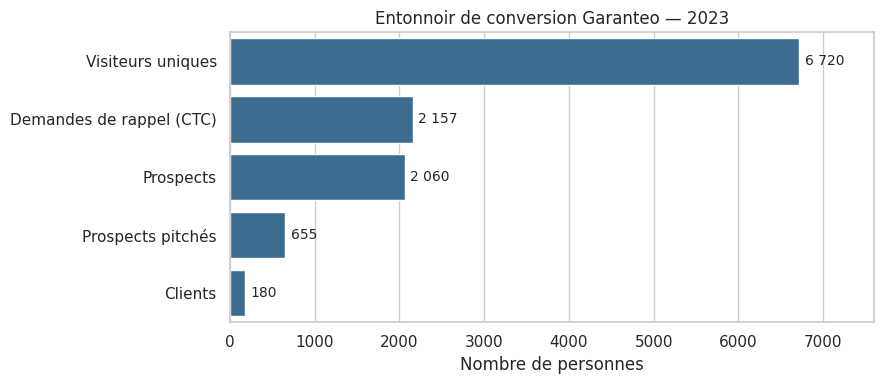

In [54]:
plt.figure(figsize=(9, 4))
sns.barplot(data=entonnoir, y="etape", x="nb_personnes", color="#2E6F9E")
for i, v in enumerate(entonnoir["nb_personnes"]):
    plt.text(v + 60, i, f"{v:,}".replace(",", " "), va="center", fontsize=10)
plt.title("Entonnoir de conversion Garanteo — 2023")
plt.xlabel("Nombre de personnes")
plt.ylabel("")
plt.xlim(0, 7600)
plt.tight_layout()
plt.show()

→ La chute est massive dès la première étape (6 720 → 2 157) puis se resserre. Visuellement, l'essentiel du volume est perdu avant même la création du prospect.

## Jointure des 4 tables

On relie `events` → `sessions` → `campaigns` → `prospects`. À chaque `merge`, on vérifie le nombre de lignes obtenu : une jointure qui duplique des lignes en silence fausserait tous les totaux.

In [55]:
# On ne garde que les événements rattachables à une campagne : ce sont les seules
# touches exploitables pour attribuer une dépense à un client.
events_camp = events[events["campaign_id"].notna()].copy()
events_camp["event_timestamp"] = pd.to_datetime(events_camp["event_timestamp"])
print("événements rattachables à une campagne :", events_camp.shape)

événements rattachables à une campagne : (19899, 14)


→ 19 899 événements sur 90 436 portent un `campaign_id`. Ce sont les seules touches exploitables pour l'attribution. Les 14 colonnes sont celles d'`events`, inchangées par le filtre.

In [56]:
events_sessions = events_camp.merge(
    sessions[["session_id", "session_started_at", "session_ended_at", "duree_min"]],
    on="session_id",
    how="left",
)
print("après jointure avec sessions  :", events_sessions.shape,
      "| lignes ajoutées :", len(events_sessions) - len(events_camp))

après jointure avec sessions  : (19899, 17) | lignes ajoutées : 0


→ 19 899 lignes, exactement autant qu'avant : **aucun `session_id` ne correspond à plusieurs sessions**, la jointure n'a pas dupliqué de lignes. 3 colonnes ajoutées (dates de session et durée).

In [57]:
events_campagnes = events_sessions.merge(campaigns, on="campaign_id", how="left")
print("après jointure avec campaigns :", events_campagnes.shape,
      "| lignes ajoutées :", len(events_campagnes) - len(events_sessions))
print("coût de campagne manquant     :", events_campagnes["total_cost"].isna().sum())

après jointure avec campaigns : (19899, 21) | lignes ajoutées : 0
coût de campagne manquant     : 0


→ 19 899 lignes inchangées et **zéro coût manquant** : les 13 campagnes ont bien été retrouvées, chaque touche porte le budget de sa campagne. 4 colonnes ajoutées (`campaign_type`, dates de campagne, `total_cost`).

In [58]:
table_jointe = events_campagnes.merge(prospects, on="user_id", how="inner")
print("table jointe finale :", table_jointe.shape)
print("prospects représentés :", table_jointe["user_id"].nunique(), "/", len(prospects))
print("touches par prospect (moyenne) :", round(len(table_jointe) / table_jointe["user_id"].nunique(), 2))

table jointe finale : (8039, 29)
prospects représentés : 2056 / 2060
touches par prospect (moyenne) : 3.91


→ 8 039 lignes pour 2 056 prospects distincts, soit **3,91 touches de campagne par prospect en moyenne**. On a beaucoup plus de lignes que de prospects, et c'est tout le problème : un même prospect a été touché par plusieurs campagnes, donc **on ne peut pas attribuer sa conversion à une seule d'entre elles sans choisir une règle**.

Le `how="inner"` est volontaire : on ne garde que les visiteurs qui sont devenus prospects, puisque c'est la seule population dont on connaît l'issue commerciale.

In [59]:
touches = table_jointe.groupby("user_id")["campaign_id"].nunique()
repartition = touches.value_counts().sort_index().rename("nb_prospects").to_frame()
repartition["part_%"] = (repartition["nb_prospects"] / repartition["nb_prospects"].sum() * 100).round(1)
repartition.index.name = "nb de campagnes distinctes"
repartition

,nb_prospects,part_%
nb de campagnes distinctes,,
1,187,9.1
2,489,23.8
3,673,32.7
4,439,21.4
5,195,9.5
6,60,2.9
7,13,0.6


→ **Seuls 187 prospects sur 2 056 (9,1 %) n'ont été touchés que par une seule campagne.** Les 90,9 % restants sont multi-touch, jusqu'à 7 campagnes différentes pour une même personne.

C'est le fait qui rend la règle d'attribution incontournable : pour plus de 9 prospects sur 10, la question « quelle campagne l'a converti ? » n'a pas de réponse évidente dans les données.

## Attribution multi-touch

Trois règles sont testées, pas une seule — l'enjeu est justement de montrer à quel point le résultat en dépend.

| Règle | Principe | Question à laquelle elle répond |
|---|---|---|
| **Premier contact** | on crédite la 1ère campagne qui a touché le prospect | qui a fait *découvrir* Garanteo ? |
| **Dernier contact** | on crédite la dernière campagne avant la conversion | qui a fait *basculer* le prospect ? |
| **Multi-touch** | on crédite *toutes* les campagnes du parcours | quelles campagnes ont *participé* ? |

La règle multi-touch a un défaut connu qu'il faut annoncer : la somme des clients attribués dépasse le nombre réel de clients (une même personne est comptée dans chaque campagne de son parcours). Elle sert de contrôle, pas de base de décision.

In [60]:
table_triee = table_jointe.sort_values("event_timestamp")

attribution_premier = table_triee.drop_duplicates(subset="user_id", keep="first")
attribution_dernier = table_triee.drop_duplicates(subset="user_id", keep="last")

print("premier contact :", attribution_premier.shape[0], "prospects")
print("dernier contact :", attribution_dernier.shape[0], "prospects")
print("prospects au total :", len(prospects))
print("prospects non attribuables :", len(prospects) - attribution_premier.shape[0])

premier contact : 2056 prospects
dernier contact : 2056 prospects
prospects au total : 2060
prospects non attribuables : 4


→ 2 056 prospects attribuables sous chaque règle (même population, seule la campagne retenue diffère). **4 prospects sur 2 060 n'ont jamais eu d'événement avec un `campaign_id`** : ils resteront non attribuables, quelle que soit la règle. C'est un écart de 0,2 %, à signaler mais sans conséquence.

### Nombre de clients par campagne, pour chaque règle

In [61]:
clients_premier = (attribution_premier[attribution_premier["is_client"] == 1]
                   .groupby("campaign_id")["user_id"].count().rename("clients_premier"))
clients_dernier = (attribution_dernier[attribution_dernier["is_client"] == 1]
                   .groupby("campaign_id")["user_id"].count().rename("clients_dernier"))
clients_multi = (table_jointe[table_jointe["is_client"] == 1]
                 .groupby("campaign_id")["user_id"].nunique().rename("clients_multi"))

clients_par_regle = (campaigns[["campaign_id", "campaign_type", "total_cost"]]
                     .merge(clients_premier, on="campaign_id", how="left")
                     .merge(clients_dernier, on="campaign_id", how="left")
                     .merge(clients_multi, on="campaign_id", how="left")
                     .fillna(0))
for col in ["clients_premier", "clients_dernier", "clients_multi"]:
    clients_par_regle[col] = clients_par_regle[col].astype(int)

print("clients réels                        :", int(prospects["is_client"].sum()))
print("somme attribuée en premier contact   :", clients_par_regle["clients_premier"].sum())
print("somme attribuée en dernier contact   :", clients_par_regle["clients_dernier"].sum())
print("somme attribuée en multi-touch       :", clients_par_regle["clients_multi"].sum())
clients_par_regle

clients réels                        : 180
somme attribuée en premier contact   : 179
somme attribuée en dernier contact   : 179
somme attribuée en multi-touch       : 554


,campaign_id,campaign_type,total_cost,clients_premier,clients_dernier,clients_multi
0,45c82b38c6,google ads,7000.0,16,12,48
1,f11dac0db6,google ads,9100.0,20,23,78
2,73dc9eab7b,google ads,8400.0,27,20,60
3,242649bfe1,google ads,2800.0,6,10,24
4,acb1a5969d,google ads,700.0,1,4,8
5,7db5e11944,google ads,700.0,1,3,7
6,f28414dfd1,google ads,6300.0,12,13,50
7,f115ad964e,google ads,4200.0,15,11,35
8,67bac78ff1,google ads,16800.0,48,45,122
9,7b9f593535,google ads,7000.0,12,22,56


→ Trois contrôles de cohérence, tous concluants :
- **179 clients attribués** en premier comme en dernier contact, contre 180 clients réels. L'écart d'exactement 1 correspond à l'un des 4 prospects non attribuables, qui se trouve être client.
- **554 en multi-touch**, soit 3,1 fois le nombre réel : c'est le double comptage annoncé, il confirme que cette règle ne peut pas servir à décider d'un budget.
- **`ca98f07be2` a 0 client en premier ET en dernier contact.** Un résultat identique sous deux règles opposées est un signal fort, indépendant du choix méthodologique.

### Calcul du CAC par campagne, pour les trois règles

→ Le coût d'acquisition (CAC) est le budget divisé par le nombre de clients. Une campagne à 0 client donne une division par zéro : on la remplace par une valeur manquante (`np.nan`) plutôt que de laisser `inf`, qui n'est ni affichable dans un graphique ni importable proprement dans Power BI.

In [62]:
cac = clients_par_regle.copy()
for regle in ["premier", "dernier", "multi"]:
    cac[f"CAC_{regle}"] = (cac["total_cost"] / cac[f"clients_{regle}"]).round(2)
# 0 client => division par zero => inf : on le remplace par une valeur manquante
cac = cac.replace([np.inf, -np.inf], np.nan)

cac[["campaign_id", "campaign_type", "total_cost",
     "clients_premier", "CAC_premier",
     "clients_dernier", "CAC_dernier",
     "clients_multi", "CAC_multi"]].sort_values("CAC_dernier", na_position="last")

,campaign_id,campaign_type,total_cost,clients_premier,CAC_premier,clients_dernier,CAC_dernier,clients_multi,CAC_multi
4,acb1a5969d,google ads,700.0,1,700.00,4,175.00,8,87.50
5,7db5e11944,google ads,700.0,1,700.00,3,233.33,7,100.00
3,242649bfe1,google ads,2800.0,6,466.67,10,280.00,24,116.67
9,7b9f593535,google ads,7000.0,12,583.33,22,318.18,56,125.00
8,67bac78ff1,google ads,16800.0,48,350.00,45,373.33,122,137.70
7,f115ad964e,google ads,4200.0,15,280.00,11,381.82,35,120.00
10,9fa01fb1a0,affiliation,3500.0,13,269.23,9,388.89,34,102.94
1,f11dac0db6,google ads,9100.0,20,455.00,23,395.65,78,116.67
11,95137568bf,affiliation,2800.0,8,350.00,7,400.00,29,96.55
2,73dc9eab7b,google ads,8400.0,27,311.11,20,420.00,60,140.00


→ Le tableau qui répond à la sous-problématique n°1 et n°2 d'un coup. Lecture en dernier contact : le CAC va de **175 €** (`acb1a5969d`) à **583 €** (`45c82b38c6`), et `ca98f07be2` n'a aucun client pour 700 € dépensés.

Mais surtout : **les colonnes `CAC_premier` et `CAC_dernier` ne classent pas les campagnes dans le même ordre du tout.** `acb1a5969d` est la plus chère en premier contact (700 €) et la moins chère en dernier contact (175 €). C'est mesuré statistiquement en section 4.

### CAC global

In [63]:
clients_totaux = int(prospects["is_client"].sum())
cac_global = budget_total / clients_totaux
print(f"budget total      : {budget_total:,.0f} €".replace(",", " "))
print(f"clients           : {clients_totaux}")
print(f"CAC global        : {cac_global:.2f} €")
print(f"coût par prospect : {budget_total / len(prospects):.2f} €")
print(f"taux de conversion prospect -> client : {prospects['is_client'].mean() * 100:.2f} %")

budget total      : 70 000 €
clients           : 180
CAC global        : 388.89 €
coût par prospect : 33.98 €
taux de conversion prospect -> client : 8.74 %


→ **CAC global : 388,89 €.** C'est la référence unique contre laquelle chaque campagne se juge : au-dessus, elle dégrade la performance moyenne ; en dessous, elle l'améliore. Coût par prospect : 33,98 €, taux de conversion prospect → client : 8,74 %.

## Coût par clic (CPC), un complément au CAC

Le CAC mélange deux choses : le prix du trafic acheté et sa qualité. Le CPC isole le prix du trafic. Si le CPC varie autant que le CAC, le problème est le prix ; s'il est stable, le problème est la qualité.

In [64]:
clics_par_campagne = events_camp.groupby("campaign_id").size().rename("nb_clics")
print("somme des clics :", clics_par_campagne.sum(), "| total events_camp :", len(events_camp))

cpc = campaigns[["campaign_id", "campaign_type", "total_cost"]].merge(
    clics_par_campagne, on="campaign_id", how="left")
cpc["CPC"] = (cpc["total_cost"] / cpc["nb_clics"]).round(4)
cpc.sort_values("CPC")

somme des clics : 19899 | total events_camp : 19899


,campaign_id,campaign_type,total_cost,nb_clics,CPC
9,7b9f593535,google ads,7000.0,2073,3.3767
11,95137568bf,affiliation,2800.0,813,3.4440
12,ca98f07be2,affiliation,700.0,202,3.4653
8,67bac78ff1,google ads,16800.0,4846,3.4668
0,45c82b38c6,google ads,7000.0,1995,3.5088
1,f11dac0db6,google ads,9100.0,2575,3.5340
5,7db5e11944,google ads,700.0,196,3.5714
10,9fa01fb1a0,affiliation,3500.0,977,3.5824
6,f28414dfd1,google ads,6300.0,1758,3.5836
3,242649bfe1,google ads,2800.0,778,3.5990


→ La somme des clics (19 899) correspond exactement au total d'`events_camp` : aucune ligne perdue dans le comptage.

**Le CPC varie de 3,38 € à 3,68 €, soit 9 % d'écart entre la campagne la moins chère et la plus chère.** À comparer au CAC, qui varie de 175 € à 583 € (×3,3) et jusqu'à l'infini pour `ca98f07be2`.

Conclusion nette : **le prix du clic n'explique quasiment rien des différences de performance.** Ce qui distingue les campagnes, c'est ce qui se passe *après* le clic. Négocier le coût du trafic ne rapporterait presque rien à Garanteo ; améliorer la qualité du trafic, beaucoup.

## Décomposition du CAC

On démontre l'affirmation ci-dessus au lieu de la supposer. Le CAC se décompose exactement en deux facteurs :

$$\text{CAC} = \frac{\text{budget}}{\text{clients}} = \frac{\text{budget} / \text{prospects}}{\text{clients} / \text{prospects}} = \frac{\text{coût par prospect}}{\text{taux de conversion}}$$

Reste à savoir lequel des deux facteurs fait bouger le CAC.

In [65]:
perf = (attribution_dernier.groupby("campaign_id")
        .agg(nb_prospects=("user_id", "nunique"),
             nb_pitches=("is_presented_prospect", "sum"),
             nb_clients=("is_client", "sum"))
        .reset_index())
perf = campaigns[["campaign_id", "campaign_type", "total_cost"]].merge(
    perf, on="campaign_id", how="left").fillna(0)
perf[["nb_prospects", "nb_pitches", "nb_clients"]] = perf[["nb_prospects", "nb_pitches", "nb_clients"]].astype(int)

perf["part_budget_%"] = (perf["total_cost"] / budget_total * 100).round(1)
perf["cout_par_prospect"] = (perf["total_cost"] / perf["nb_prospects"]).round(2)
perf["taux_conversion_%"] = (perf["nb_clients"] / perf["nb_prospects"] * 100).round(2)
perf["CAC"] = (perf["total_cost"] / perf["nb_clients"]).replace([np.inf], np.nan).round(2)

perf.sort_values("CAC", na_position="last")[
    ["campaign_id", "campaign_type", "total_cost", "part_budget_%", "nb_prospects",
     "nb_clients", "cout_par_prospect", "taux_conversion_%", "CAC"]]

,campaign_id,campaign_type,total_cost,part_budget_%,nb_prospects,nb_clients,cout_par_prospect,taux_conversion_%,CAC
4,acb1a5969d,google ads,700.0,1.0,22,4,31.82,18.18,175.00
5,7db5e11944,google ads,700.0,1.0,21,3,33.33,14.29,233.33
3,242649bfe1,google ads,2800.0,4.0,64,10,43.75,15.62,280.00
9,7b9f593535,google ads,7000.0,10.0,211,22,33.18,10.43,318.18
8,67bac78ff1,google ads,16800.0,24.0,496,45,33.87,9.07,373.33
7,f115ad964e,google ads,4200.0,6.0,126,11,33.33,8.73,381.82
10,9fa01fb1a0,affiliation,3500.0,5.0,103,9,33.98,8.74,388.89
1,f11dac0db6,google ads,9100.0,13.0,302,23,30.13,7.62,395.65
11,95137568bf,affiliation,2800.0,4.0,73,7,38.36,9.59,400.00
2,73dc9eab7b,google ads,8400.0,12.0,248,20,33.87,8.06,420.00


→ Le tableau de bord complet par campagne, en dernier contact. On y voit déjà que le coût par prospect est remarquablement stable (28 € à 44 €) alors que le taux de conversion va de 0 % à 18,18 %.

In [66]:
amplitudes = pd.DataFrame([
    ["coût par prospect", perf["cout_par_prospect"].min(), perf["cout_par_prospect"].max()],
    ["taux de conversion (%)", perf.loc[perf.nb_clients > 0, "taux_conversion_%"].min(),
     perf["taux_conversion_%"].max()],
    ["CAC (€)", perf["CAC"].min(), perf["CAC"].max()],
], columns=["facteur", "min", "max"])
amplitudes["rapport max/min"] = (amplitudes["max"] / amplitudes["min"]).round(2)
amplitudes

,facteur,min,max,rapport max/min
0,coût par prospect,28.00,43.75,1.56
1,taux de conversion (%),6.25,18.18,2.91
2,CAC (€),175.00,583.33,3.33


→ Le verdict est sans ambiguïté :

| Facteur | Amplitude |
|---|---|
| Coût par prospect | ×1,56 |
| Taux de conversion | ×2,91 |
| **CAC** | **×3,33** |

Le CAC varie 2 fois plus que le coût du trafic. **C'est la conversion qui pilote le CAC, pas le prix d'achat du trafic.** Ce sera confirmé par le calcul de corrélation en section 4.

Le levier pour Garanteo n'est donc pas de renégocier ses enchères Google Ads, c'est de réallouer le budget vers les campagnes qui amènent du trafic qui convertit.

## Évolution mensuelle

Pour le suivi dans le temps demandé par le client (« un dashboard réutilisable, pas une photo à un instant T »).

In [67]:
evolution_mensuelle = (prospects.groupby("mois_creation")
                       .agg(nb_prospects=("prospect_id", "count"),
                            nb_clients=("is_client", "sum"))
                       .reset_index())
evolution_mensuelle["taux_conversion_%"] = (
    evolution_mensuelle["nb_clients"] / evolution_mensuelle["nb_prospects"] * 100).round(2)

print("contrôle — somme prospects :", evolution_mensuelle["nb_prospects"].sum(),
      "| somme clients :", evolution_mensuelle["nb_clients"].sum())
evolution_mensuelle

contrôle — somme prospects : 2060 | somme clients : 180


,mois_creation,nb_prospects,nb_clients,taux_conversion_%
0,2023-01,206,16,7.77
1,2023-02,185,19,10.27
2,2023-03,184,20,10.87
3,2023-04,197,12,6.09
4,2023-05,160,19,11.88
5,2023-06,161,15,9.32
6,2023-07,180,12,6.67
7,2023-08,186,16,8.60
8,2023-09,156,11,7.05
9,2023-10,148,17,11.49


→ 12 lignes, une par mois. La somme retombe exactement sur 2 060 prospects et 180 clients : aucune ligne perdue dans l'agrégation.

In [68]:
s1 = evolution_mensuelle.iloc[:6]
s2 = evolution_mensuelle.iloc[6:]
semestres = pd.DataFrame({
    "semestre": ["S1 (janv-juin)", "S2 (juil-déc)"],
    "prospects": [s1.nb_prospects.sum(), s2.nb_prospects.sum()],
    "clients": [s1.nb_clients.sum(), s2.nb_clients.sum()],
})
semestres["taux_conversion_%"] = (semestres.clients / semestres.prospects * 100).round(2)
print(semestres.to_string(index=False))
print(f"\névolution du volume de prospects S1 -> S2 : "
      f"{(s2.nb_prospects.sum() / s1.nb_prospects.sum() - 1) * 100:+.1f} %")

      semestre  prospects  clients  taux_conversion_%
S1 (janv-juin)       1093      101               9.24
 S2 (juil-déc)        967       79               8.17

évolution du volume de prospects S1 -> S2 : -11.5 %


→ **Le volume de prospects baisse de 11,5 % entre les deux semestres** (1 093 → 967), et le taux de conversion suit la même pente, en plus discret (9,24 % → 8,17 %).

À budget constant sur l'année (toutes les campagnes courent du 01/01 au 31/12), une baisse du volume de prospects signifie un CAC qui se dégrade mécaniquement au fil de l'année. C'est un argument de plus pour la révision budgétaire : le dispositif actuel s'essouffle.

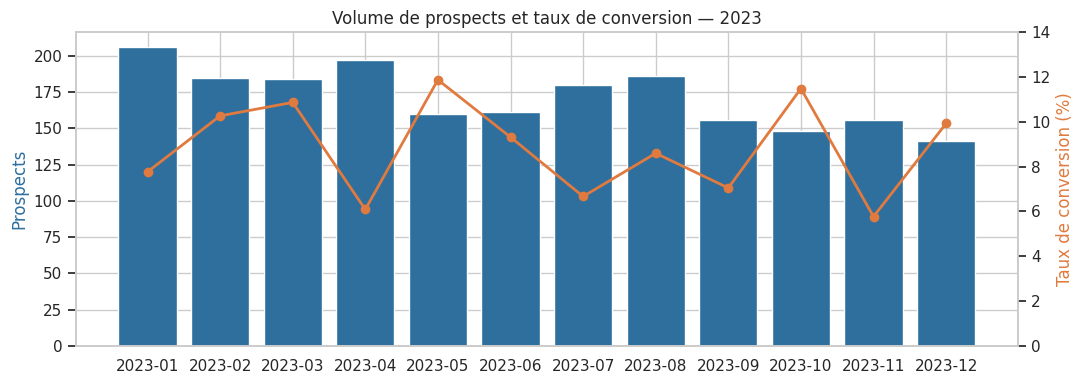

In [69]:
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(evolution_mensuelle["mois_creation"], evolution_mensuelle["nb_prospects"],
        color="#2E6F9E", label="Prospects")
ax1.set_ylabel("Prospects", color="#2E6F9E")
ax1.set_xlabel("")
ax2 = ax1.twinx()
ax2.plot(evolution_mensuelle["mois_creation"], evolution_mensuelle["taux_conversion_%"],
         color="#E07A3F", marker="o", linewidth=2, label="Taux de conversion (%)")
ax2.set_ylabel("Taux de conversion (%)", color="#E07A3F")
ax2.set_ylim(0, 14)
ax2.grid(False)
plt.title("Volume de prospects et taux de conversion — 2023")
fig.tight_layout()
plt.show()

→ La tendance baissière du volume est nette sur l'année. Le taux de conversion oscille sans tendance franche, ce qui confirme que le problème est un problème de **volume de trafic qualifié**, pas d'efficacité commerciale.

## Test du pitch — préparation du tableau

In [70]:
pitch_test = (prospects.groupby("is_presented_prospect")
              .agg(nb_prospects=("prospect_id", "count"),
                   nb_clients=("is_client", "sum"))
              .reset_index())
pitch_test["taux_conversion"] = (pitch_test["nb_clients"] / pitch_test["nb_prospects"] * 100).round(2)
pitch_test["groupe"] = pitch_test["is_presented_prospect"].map({0: "Non pitché", 1: "Pitché"})
pitch_test

,is_presented_prospect,nb_prospects,nb_clients,taux_conversion,groupe
0,0,1405,133,9.47,Non pitché
1,1,655,47,7.18,Pitché


→ Non pitchés : 1 405 prospects, 133 clients, **9,47 %** de conversion. Pitchés : 655 prospects, 47 clients, **7,18 %**. Les prospects qui ont reçu un pitch convertissent moins. Le test statistique de la section 4 dira si cet écart est réel ou dû au hasard.

## Tables d'export pour le dashboard

Sept tables exportées en CSV, chacune alimentant un visuel précis du dashboard Power BI. On exporte des tables agrégées plutôt que les 90 436 lignes d'`events` : le dashboard reste léger et les calculs restent traçables dans ce notebook.

In [71]:
# 1. CAC par campagne et par regle d'attribution (format long, pour le segment Power BI)
exports = []
for regle, libelle in [("premier", "premier contact"), ("dernier", "dernier contact"),
                       ("multi", "multi-touch")]:
    bloc = cac[["campaign_id", "campaign_type", "total_cost",
                f"clients_{regle}", f"CAC_{regle}"]].copy()
    bloc.columns = ["campaign_id", "campaign_type", "total_cost", "nb_clients", "CAC"]
    bloc["regle_attribution"] = libelle
    exports.append(bloc)
cac_par_campagne = pd.concat(exports, ignore_index=True)
print(cac_par_campagne.shape, "= 13 campagnes x 3 règles")
cac_par_campagne.head(4)

(39, 6) = 13 campagnes x 3 règles


,campaign_id,campaign_type,total_cost,nb_clients,CAC,regle_attribution
0,45c82b38c6,google ads,7000.0,16,437.50,premier contact
1,f11dac0db6,google ads,9100.0,20,455.00,premier contact
2,73dc9eab7b,google ads,8400.0,27,311.11,premier contact
3,242649bfe1,google ads,2800.0,6,466.67,premier contact


→ 39 lignes (13 campagnes × 3 règles) en format long. Ce format permet un **segment (slicer)** dans Power BI : l'utilisateur bascule d'une règle à l'autre et tous les visuels se recalculent, au lieu d'avoir trois tableaux figés côte à côte. Les `CAC` de `ca98f07be2` sont vides (0 client), pas `inf`.

In [72]:
# 2. Performance detaillee par campagne (regle dernier contact retenue)
perf_campagne = perf.copy()

# 3. Entonnoir  4. Evolution mensuelle  5. Test du pitch  6. CPC : deja calcules
# 7. Comparatif des rangs entre les 3 regles
rangs = cac[["campaign_id", "campaign_type", "total_cost"]].copy()
for regle in ["premier", "dernier", "multi"]:
    rangs[f"CAC_{regle}"] = cac[f"CAC_{regle}"]
    rangs[f"rang_{regle}"] = cac[f"CAC_{regle}"].rank(na_option="bottom")
rangs["rang_moyen"] = rangs[["rang_premier", "rang_dernier", "rang_multi"]].mean(axis=1).round(2)
rangs = rangs.sort_values("rang_moyen")
rangs

,campaign_id,campaign_type,total_cost,CAC_premier,rang_premier,CAC_dernier,rang_dernier,CAC_multi,rang_multi,rang_moyen
10,9fa01fb1a0,affiliation,3500.0,269.23,1.0,388.89,7.0,102.94,4.0,4.00
4,acb1a5969d,google ads,700.0,700.00,11.5,175.00,1.0,87.50,1.0,4.50
7,f115ad964e,google ads,4200.0,280.00,2.0,381.82,6.0,120.00,7.0,5.00
11,95137568bf,affiliation,2800.0,350.00,4.5,400.00,9.0,96.55,2.0,5.17
3,242649bfe1,google ads,2800.0,466.67,8.0,280.00,3.0,116.67,5.5,5.50
5,7db5e11944,google ads,700.0,700.00,11.5,233.33,2.0,100.00,3.0,5.50
8,67bac78ff1,google ads,16800.0,350.00,4.5,373.33,5.0,137.70,10.0,6.50
1,f11dac0db6,google ads,9100.0,455.00,7.0,395.65,8.0,116.67,5.5,6.83
9,7b9f593535,google ads,7000.0,583.33,10.0,318.18,4.0,125.00,8.0,7.33
2,73dc9eab7b,google ads,8400.0,311.11,3.0,420.00,10.0,140.00,11.0,8.00


→ **Le tableau le plus utile de tout le projet pour décider.** Le rang moyen sur les 3 règles dit quelles conclusions tiennent quelle que soit la méthode d'attribution :

- **`ca98f07be2` est dernière (13/13) sous les trois règles.** C'est la seule campagne dans ce cas : la recommandation de la couper ne dépend d'aucun choix méthodologique.
- **`45c82b38c6` est 12e sur 13 en dernier contact et en multi-touch**, pour 7 000 € (10 % du budget). C'est là qu'est réellement l'argent.
- **`acb1a5969d` est 1re en dernier contact et en multi-touch, mais 11e-12e en premier contact.** Le classement le plus flatteur est aussi le moins stable — on verra en section 4 que c'est un problème de taille d'échantillon (22 prospects seulement).
- **`9fa01fb1a0` (affiliation, 3 500 €) a le meilleur rang moyen (4,0)** avec un volume correct. C'est le candidat au renforcement le plus solide.

In [73]:
tables_a_exporter = {
    "cac_par_campagne": cac_par_campagne,
    "perf_campagne": perf_campagne,
    "entonnoir": entonnoir,
    "evolution_mensuelle": evolution_mensuelle,
    "pitch_test": pitch_test,
    "cpc_par_campagne": cpc,
    "rangs_attribution": rangs,
}
for nom, table in tables_a_exporter.items():
    table.to_csv(f"{DOSSIER_PROPRE}/{nom}.csv", index=False)
    print(f"{nom + '.csv':28s} {table.shape[0]:>4d} lignes x {table.shape[1]:>2d} colonnes")

cac_par_campagne.csv           39 lignes x  6 colonnes
perf_campagne.csv              13 lignes x 10 colonnes
entonnoir.csv                   5 lignes x  4 colonnes
evolution_mensuelle.csv        12 lignes x  4 colonnes
pitch_test.csv                  2 lignes x  5 colonnes
cpc_par_campagne.csv           13 lignes x  5 colonnes
rangs_attribution.csv          13 lignes x 10 colonnes


→ Les 7 tables d'export sont écrites dans le dossier `propre/` (`DOSSIER_PROPRE`), prêtes pour Power BI. Chaque chiffre du dashboard est donc traçable jusqu'à une cellule de ce notebook.

# 4. Analyse statistiques

Sept analyses, dans cet ordre :

| # | Question | Méthode |
|---|---|---|
| 1 | Y a-t-il des durées de session aberrantes ? | boxplot + méthode IQR |
| 2 | Comment se distribue la durée de session ? | histogramme |
| 3 | Le pitch téléphonique fait-il baisser la conversion ? | khi-deux, test t, Fisher, intervalle de confiance |
| 4 | La campagne influence-t-elle la conversion ? | khi-deux global + V de Cramér |
| 5 | Quel facteur pilote le CAC ? | corrélation de Pearson |
| 6 | Le classement des campagnes est-il robuste à la règle d'attribution ? | corrélation de Spearman sur les rangs |
| 7 | Existe-t-il un profil de client à cibler ? | khi-deux par segment (canal, device, pays, genre, âge) |

**Convention pour tous les tests** : seuil α = 0,05. H₀ = « il n'y a pas de différence ». Si p < 0,05 on rejette H₀ (l'écart est réel) ; si p ≥ 0,05 on ne peut pas rejeter H₀ (l'écart observé est compatible avec le hasard). Un test non significatif ne prouve pas l'absence d'effet, il prouve qu'on n'a pas assez de données pour le trancher — nuance qui change tout dans une recommandation.

## 4.1 Détection des valeurs aberrantes (durée de session)

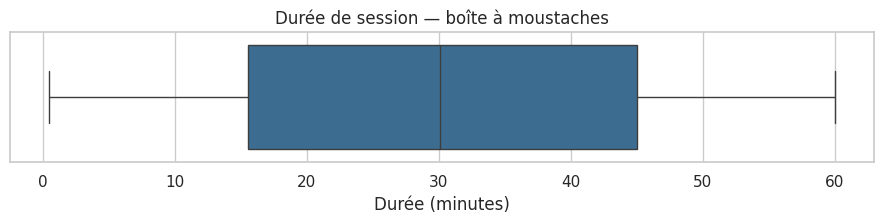

In [74]:
plt.figure(figsize=(9, 2.4))
sns.boxplot(x=sessions["duree_min"], color="#2E6F9E")
plt.title("Durée de session — boîte à moustaches")
plt.xlabel("Durée (minutes)")
plt.tight_layout()
plt.show()

→ La boîte va d'environ 15,5 (Q1) à 45 (Q3), médiane à 30, et les moustaches s'étendent jusqu'au minimum (0,5) et au maximum (60) **sans aucun point isolé au-delà**. Sur un boxplot, un point détaché des moustaches signale une valeur aberrante ; ici il n'y en a aucun. À confirmer par le calcul.

In [75]:
Q1 = sessions["duree_min"].quantile(0.25)
Q3 = sessions["duree_min"].quantile(0.75)
IQR = Q3 - Q1
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.2f} | Q3 = {Q3:.2f} | IQR = {IQR:.2f}")
print(f"bornes de Tukey : [{borne_basse:.2f} ; {borne_haute:.2f}]")

aberrantes = sessions[(sessions["duree_min"] < borne_basse) | (sessions["duree_min"] > borne_haute)]
print("valeurs aberrantes détectées :", len(aberrantes))

Q1 = 15.52 | Q3 = 45.02 | IQR = 29.50
bornes de Tukey : [-28.73 ; 89.27]
valeurs aberrantes détectées : 0


→ **0 valeur aberrante** par la méthode IQR (bornes de Tukey : −28,73 à 89,27 min). La borne basse négative n'a pas de sens concret (une durée ne peut pas être négative), donc seule la borne haute compte : le maximum réel (60 min) est largement en dessous de 89,27.

Point important qui pourrait sembler contradictoire : **ça ne contredit pas le plafond à 60 min repéré en section 3.** Les deux méthodes répondent à deux questions différentes.
- L'**IQR** détecte des valeurs statistiquement extrêmes *par rapport à la distribution observée* ; ici la distribution est si étalée que 60 min n'en est pas une.
- Le **plafond technique** a été repéré autrement : par le fait qu'un maximum tombe pile sur une valeur ronde, ce qui n'arrive pas par hasard sur une variable continue.

Aucune valeur n'est statistiquement aberrante, et pourtant une limite structurelle de l'outil de tracking existe. Les deux analyses sont complémentaires.

## 4.2 Distribution de la durée de session

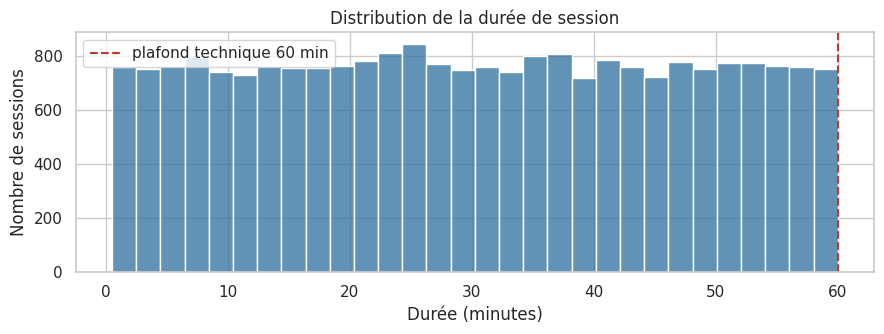

In [76]:
plt.figure(figsize=(9, 3.5))
sns.histplot(sessions["duree_min"], bins=30, color="#2E6F9E")
plt.axvline(60, color="#C0392B", linestyle="--", linewidth=1.5, label="plafond technique 60 min")
plt.title("Distribution de la durée de session")
plt.xlabel("Durée (minutes)")
plt.ylabel("Nombre de sessions")
plt.legend()
plt.tight_layout()
plt.show()

→ Distribution **quasiment plate** entre 0 et 60 minutes : les barres oscillent toutes autour de 750-850 sessions, sans aucun pic qui indiquerait une durée « typique ». `duree_min` ne suit donc pas une loi normale en cloche, les visiteurs se répartissent presque uniformément sur toute la plage.

La **coupure nette à 60 minutes**, sans aucune barre au-delà, confirme visuellement le plafond technique : une vraie distribution naturelle se serait éteinte progressivement, pas d'un coup.

Cette forme plate explique aussi pourquoi le boxplot n'a détecté aucune valeur aberrante : sans pic central ni longue traîne, la méthode IQR n'a rien d'extrême à signaler.

## 4.3 Le pitch téléphonique fait-il baisser la conversion ?

C'est la sous-problématique n°3 et la contre-intuition repérée à l'audit : les prospects qui ont reçu un pitch commercial au téléphone convertissent **moins** (7,18 %) que ceux qui n'en ont pas reçu (9,47 %). Avant d'en conclure quoi que ce soit, il faut savoir si cet écart est réel ou dû au hasard de l'échantillon.

**Choix du test.** On compare **deux proportions** (deux taux de conversion) sur deux groupes indépendants. Le test de référence est le **khi-deux d'indépendance** sur le tableau de contingence. On calcule aussi le test t (pratiqué en cours DAFT, valide ici car les variables sont binaires et les effectifs grands) et le test exact de Fisher, pour vérifier que la conclusion ne dépend pas du test choisi.

In [77]:
contingence = pd.crosstab(prospects["is_presented_prospect"], prospects["is_client"])
contingence.index = ["Non pitché", "Pitché"]
contingence.columns = ["Non client", "Client"]
contingence

,Non client,Client
Non pitché,1272,133
Pitché,608,47


In [78]:
chi2, p_chi2, dof, attendus = stats.chi2_contingency(contingence)
print("--- Khi-deux d'indépendance (correction de Yates par défaut) ---")
print(f"chi2 = {chi2:.4f} | p-value = {p_chi2:.4f} | degrés de liberté = {dof}")
print("\neffectifs attendus sous H0 :")
print(pd.DataFrame(attendus.round(1), index=contingence.index, columns=contingence.columns))
print("\nplus petit effectif attendu :", round(attendus.min(), 1),
      "-> condition du khi-deux (>= 5)", "respectée" if attendus.min() >= 5 else "NON respectée")

--- Khi-deux d'indépendance (correction de Yates par défaut) ---
chi2 = 2.6592 | p-value = 0.1030 | degrés de liberté = 1

effectifs attendus sous H0 :
            Non client  Client
Non pitché      1282.2   122.8
Pitché           597.8    57.2

plus petit effectif attendu : 57.2 -> condition du khi-deux (>= 5) respectée


→ **p = 0,1030**, au-dessus du seuil de 0,05. Les effectifs attendus sont tous largement supérieurs à 5 (le plus petit vaut 57,2), donc le khi-deux est bien applicable : le résultat est fiable, il n'est pas dû à une condition d'application violée.

In [79]:
print("--- Trois autres tests pour vérifier la robustesse de la conclusion ---")

chi2_nc, p_nc, _, _ = stats.chi2_contingency(contingence, correction=False)
print(f"khi-deux sans correction de Yates : p = {p_nc:.4f}")

groupe_pitche = prospects[prospects["is_presented_prospect"] == 1]["is_client"]
groupe_non_pitche = prospects[prospects["is_presented_prospect"] == 0]["is_client"]
t_stat, p_t = stats.ttest_ind(groupe_pitche, groupe_non_pitche, equal_var=False)
print(f"test t de Welch                   : t = {t_stat:.4f}, p = {p_t:.4f}")

odds, p_fisher = stats.fisher_exact(contingence)
print(f"test exact de Fisher              : odds ratio = {odds:.4f}, p = {p_fisher:.4f}")

print("\n=> les 4 tests donnent une p-value entre 0,073 et 0,103 : tous au-dessus de 0,05.")

--- Trois autres tests pour vérifier la robustesse de la conclusion ---
khi-deux sans correction de Yates : p = 0.0864
test t de Welch                   : t = -1.7948, p = 0.0729
test exact de Fisher              : odds ratio = 0.7393, p = 0.0939

=> les 4 tests donnent une p-value entre 0,073 et 0,103 : tous au-dessus de 0,05.


→ Les quatre tests convergent : **p entre 0,073 et 0,103, tous au-dessus de 0,05**. La conclusion ne dépend donc pas du test choisi, ce qui la rend solide. On ne peut pas affirmer que le pitch fait baisser la conversion.

In [80]:
def ic_proportion(succes, total, z=1.96):
    p = succes / total
    marge = z * np.sqrt(p * (1 - p) / total)
    return p * 100, (p - marge) * 100, (p + marge) * 100

ic = pd.DataFrame([
    ["Non pitché", 1405, 133, *ic_proportion(133, 1405)],
    ["Pitché", 655, 47, *ic_proportion(47, 655)],
], columns=["groupe", "prospects", "clients", "taux_%", "IC95_bas_%", "IC95_haut_%"]).round(2)
print(ic.to_string(index=False))

p1, p2 = 133 / 1405, 47 / 655
diff = p1 - p2
se_diff = np.sqrt(p1 * (1 - p1) / 1405 + p2 * (1 - p2) / 655)
print(f"\nécart (non pitchés - pitchés) : {diff * 100:+.2f} points de pourcentage")
print(f"IC 95 % de l'écart : [{(diff - 1.96 * se_diff) * 100:+.2f} ; {(diff + 1.96 * se_diff) * 100:+.2f}] points")

    groupe  prospects  clients  taux_%  IC95_bas_%  IC95_haut_%
Non pitché       1405      133    9.47        7.94        11.00
    Pitché        655       47    7.18        5.20         9.15

écart (non pitchés - pitchés) : +2.29 points de pourcentage
IC 95 % de l'écart : [-0.21 ; +4.79] points


→ L'intervalle de confiance dit la même chose que la p-value, mais de façon plus parlante pour le client :

- Non pitchés : 9,47 %, IC 95 % **[7,94 % ; 11,00 %]**
- Pitchés : 7,18 %, IC 95 % **[5,20 % ; 9,15 %]**
- Écart en faveur des non pitchés : **+2,29 points**, IC 95 % **[−0,21 ; +4,79]**

**Les deux intervalles se chevauchent**, et l'intervalle de l'écart contient 0. Autrement dit : avec ces données, le vrai effet du pitch peut aussi bien être nul qu'une baisse de 4,8 points. On ne peut pas trancher.

### Le pitch est-il donné aux mauvais prospects ? (contrôle du biais de sélection)

Si les commerciaux appelaient en priorité les prospects les moins prometteurs, l'écart observé s'expliquerait par le choix des personnes appelées, pas par le pitch lui-même. On vérifie.

In [81]:
print("--- le pitch est-il corrélé au profil du prospect ? ---")
ct_genre = pd.crosstab(prospects["gender"], prospects["is_presented_prospect"])
print(f"genre x pitch          : p = {stats.chi2_contingency(ct_genre)[1]:.4f}")

ct_age = pd.crosstab(prospects["tranche_age"], prospects["is_presented_prospect"])
print(f"tranche d'âge x pitch  : p = {stats.chi2_contingency(ct_age)[1]:.4f}")

ct_camp = pd.crosstab(attribution_dernier["campaign_id"], attribution_dernier["is_presented_prospect"])
print(f"campagne x pitch       : p = {stats.chi2_contingency(ct_camp)[1]:.4f}")

print(f"\nâge moyen pitchés : {prospects[prospects.is_presented_prospect == 1].age.mean():.2f} ans")
print(f"âge moyen non pitchés : {prospects[prospects.is_presented_prospect == 0].age.mean():.2f} ans")

--- le pitch est-il corrélé au profil du prospect ? ---
genre x pitch          : p = 0.8730
tranche d'âge x pitch  : p = 0.1249
campagne x pitch       : p = 0.7024

âge moyen pitchés : 51.46 ans
âge moyen non pitchés : 51.31 ans


→ **Aucun lien** entre le fait d'être pitché et le genre (p = 0,87), la tranche d'âge (p = 0,12) ou la campagne d'origine (p = 0,70), et un âge moyen identique (51,5 vs 51,3 ans). Le pitch n'est donc pas ciblé sur un profil particulier : il n'y a pas de biais de sélection évident qui expliquerait l'écart. C'est un argument en faveur de la réalité de l'effet — mais l'échantillon reste trop petit pour le prouver.

In [82]:
print("--- l'écart va-t-il dans le même sens campagne par campagne ? ---")
grosses = perf[perf.nb_prospects >= 150].campaign_id.tolist()
lignes = []
for cid in grosses:
    s = attribution_dernier[attribution_dernier.campaign_id == cid]
    t = s.groupby("is_presented_prospect")["is_client"].agg(["size", "sum"])
    if len(t) == 2:
        lignes.append([cid,
                       t.loc[0, "size"], round(t.loc[0, "sum"] / t.loc[0, "size"] * 100, 2),
                       t.loc[1, "size"], round(t.loc[1, "sum"] / t.loc[1, "size"] * 100, 2)])
strat = pd.DataFrame(lignes, columns=["campaign_id", "n_non_pitché", "taux_non_pitché_%",
                                      "n_pitché", "taux_pitché_%"])
strat["écart_pts"] = (strat["taux_pitché_%"] - strat["taux_non_pitché_%"]).round(2)
strat

--- l'écart va-t-il dans le même sens campagne par campagne ? ---


,campaign_id,n_non_pitché,taux_non_pitché_%,n_pitché,taux_pitché_%,écart_pts
0,45c82b38c6,136,6.62,56,5.36,-1.26
1,f11dac0db6,207,9.18,95,4.21,-4.97
2,73dc9eab7b,157,9.55,91,5.49,-4.06
3,f28414dfd1,115,9.57,58,3.45,-6.12
4,67bac78ff1,338,9.17,158,8.86,-0.31
5,7b9f593535,142,11.27,69,8.70,-2.57


→ **L'écart va dans le même sens sur les 6 grosses campagnes sans exception** : les pitchés convertissent moins partout, de −0,31 à −6,12 points. Sur 6 campagnes indépendantes, obtenir 6 fois le même sens par le seul hasard a une probabilité de 1/2⁶ = 1,6 %.

C'est un indice de cohérence fort, mais qui ne remplace pas un test sur l'ensemble : chaque sous-échantillon est trop petit pour être concluant seul.

### Conclusion du test 4.3

**On ne peut pas affirmer statistiquement que le pitch téléphonique fait baisser la conversion** (p = 0,10 ; IC de l'écart [−0,21 ; +4,79] points, qui contient 0).

Mais trois éléments convergent vers une tendance réelle plutôt que vers un artefact :
1. Les 4 tests donnent une p-value proche du seuil (0,073 à 0,103), pas un résultat franchement nul
2. Le pitch n'est pas ciblé sur un profil de prospect particulier — pas de biais de sélection identifié
3. L'écart va dans le même sens sur les 6 grosses campagnes prises séparément (probabilité 1,6 % par hasard)

**Recommandation** : ne pas couper le pitch sur la seule base de ce résultat, ce serait une décision non fondée. En revanche, comme le pitch coûte du temps commercial et que rien ne prouve qu'il rapporte, mettre en place un **test A/B propre** : sur les prochains prospects, tirer au sort qui est pitché et qui ne l'est pas. Un échantillon d'environ 1 500 prospects par groupe permettrait de trancher un écart de 2 points au seuil de 5 %.

À noter enfin que seuls 655 prospects sur 2 060 ont été pitchés : **68 % des prospects ne sont jamais joints**. La question la plus rentable n'est peut-être pas « le pitch marche-t-il ? » mais « pourquoi ne joint-on que 3 prospects sur 10 ? ».

## 4.4 La campagne influence-t-elle la conversion ?

Le tableau de la section 3 montre des taux de conversion allant de 0 % à 18,18 % selon la campagne. Ces écarts sont-ils réels, ou est-ce le bruit attendu quand on découpe 2 056 prospects en 13 groupes ? C'est la question qui décide si les recommandations sont fondées.

In [83]:
ct_camp_client = pd.crosstab(attribution_dernier["campaign_id"], attribution_dernier["is_client"])
ct_camp_client.columns = ["Non client", "Client"]
chi2_c, p_c, dof_c, att_c = stats.chi2_contingency(ct_camp_client)

print("--- Khi-deux : campagne (dernier contact) x conversion ---")
print(f"chi2 = {chi2_c:.4f} | p-value = {p_c:.4f} | degrés de liberté = {dof_c}")
v_cramer = np.sqrt(chi2_c / (ct_camp_client.values.sum() * (min(ct_camp_client.shape) - 1)))
print(f"V de Cramér = {v_cramer:.4f}  (0 = aucun lien, 1 = lien parfait)")
print(f"\ncellules avec un effectif attendu < 5 : {(att_c < 5).sum()} sur {att_c.size}")
ct_camp_client

--- Khi-deux : campagne (dernier contact) x conversion ---
chi2 = 12.8342 | p-value = 0.3812 | degrés de liberté = 12
V de Cramér = 0.0790  (0 = aucun lien, 1 = lien parfait)

cellules avec un effectif attendu < 5 : 3 sur 26


,Non client,Client
campaign_id,,
242649bfe1,54,10
45c82b38c6,180,12
67bac78ff1,451,45
73dc9eab7b,228,20
7b9f593535,189,22
7db5e11944,18,3
95137568bf,66,7
9fa01fb1a0,94,9
acb1a5969d,18,4


→ **p = 0,3812, très au-dessus de 0,05**, et un V de Cramér de 0,079 (lien quasi nul). Mais 3 cellules ont un effectif attendu inférieur à 5, ce qui viole la condition d'application du khi-deux. Il faut regrouper les petites campagnes avant de conclure.

In [84]:
taille = attribution_dernier.groupby("campaign_id").size()
petites = taille[taille < 100].index.tolist()
print("campagnes regroupées (moins de 100 prospects) :", petites)

ad_grp = attribution_dernier.copy()
ad_grp["campagne_groupee"] = np.where(ad_grp["campaign_id"].isin(petites),
                                     "Petites (n<100)", ad_grp["campaign_id"])
ct_grp = pd.crosstab(ad_grp["campagne_groupee"], ad_grp["is_client"])
chi2_g, p_g, dof_g, att_g = stats.chi2_contingency(ct_grp)
print(f"\nchi2 = {chi2_g:.4f} | p-value = {p_g:.4f} | ddl = {dof_g}")
print(f"cellules avec effectif attendu < 5 : {(att_g < 5).sum()} -> condition respectée")

campagnes regroupées (moins de 100 prospects) : ['242649bfe1', '7db5e11944', '95137568bf', 'acb1a5969d', 'ca98f07be2']

chi2 = 5.5393 | p-value = 0.6987 | ddl = 8
cellules avec effectif attendu < 5 : 0 -> condition respectée


→ Après regroupement, la condition d'application est respectée et le résultat est encore plus net : **p = 0,6987**.

**Conclusion, et c'est le point le plus important du projet à porter à l'oral : on ne peut pas prouver statistiquement que les campagnes convertissent différemment les unes des autres.** Les écarts de taux de conversion observés (0 % à 18,18 %) sont compatibles avec du simple hasard d'échantillonnage, parce que 180 clients répartis sur 13 campagnes font des effectifs trop petits par campagne.

Ce que ça change pour la recommandation :
- On ne peut **pas** dire « telle campagne convertit mieux, c'est prouvé »
- On **peut** dire « voici la meilleure décision possible avec l'information disponible, et voici son niveau d'incertitude »
- La recommandation doit s'appuyer sur ce qui est **stable** (les conclusions identiques sous les 3 règles d'attribution) plutôt que sur des écarts non significatifs

C'est aussi ce qui justifie de livrer un **dashboard** plutôt qu'un simple rapport : au fil des mois, les effectifs grandiront et les écarts deviendront mesurables.

In [85]:
def wilson(succes, total, z=1.96):
    if total == 0:
        return (np.nan, np.nan)
    p = succes / total
    d = 1 + z**2 / total
    centre = (p + z**2 / (2 * total)) / d
    demi = z * np.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / d
    return round((centre - demi) * 100, 2), round((centre + demi) * 100, 2)

taux_global = prospects["is_client"].mean()
lignes = []
for _, r in perf.iterrows():
    n, x = int(r.nb_prospects), int(r.nb_clients)
    bas, haut = wilson(x, n)
    p_bin = stats.binomtest(x, n, taux_global).pvalue if n > 0 else np.nan
    lignes.append([r.campaign_id, r.campaign_type, r.total_cost, n, x,
                   round(x / n * 100, 2) if n else np.nan, bas, haut,
                   r.CAC, round(p_bin, 4)])
fiabilite = pd.DataFrame(lignes, columns=[
    "campaign_id", "type", "budget", "n_prospects", "clients", "taux_%",
    "IC95_bas_%", "IC95_haut_%", "CAC", "p_vs_taux_global"])
fiabilite.sort_values("CAC", na_position="last")

,campaign_id,type,budget,n_prospects,clients,taux_%,IC95_bas_%,IC95_haut_%,CAC,p_vs_taux_global
4,acb1a5969d,google ads,700.0,22,4,18.18,7.31,38.52,175.00,0.1203
5,7db5e11944,google ads,700.0,21,3,14.29,4.98,34.64,233.33,0.4231
3,242649bfe1,google ads,2800.0,64,10,15.62,8.71,26.43,280.00,0.0708
9,7b9f593535,google ads,7000.0,211,22,10.43,6.99,15.28,318.18,0.3920
8,67bac78ff1,google ads,16800.0,496,45,9.07,6.85,11.92,373.33,0.7508
7,f115ad964e,google ads,4200.0,126,11,8.73,4.94,14.96,381.82,1.0000
10,9fa01fb1a0,affiliation,3500.0,103,9,8.74,4.67,15.78,388.89,1.0000
1,f11dac0db6,google ads,9100.0,302,23,7.62,5.13,11.17,395.65,0.5419
11,95137568bf,affiliation,2800.0,73,7,9.59,4.72,18.50,400.00,0.6819
2,73dc9eab7b,google ads,8400.0,248,20,8.06,5.28,12.13,420.00,0.8219


→ Le tableau qui dit **à quel point on peut faire confiance à chaque CAC**. Deux enseignements :

1. **Aucune campagne n'a un taux de conversion significativement différent du taux global de 8,74 %** (toutes les p-values ≥ 0,07). Confirmation directe du khi-deux global.

2. **Les intervalles de confiance des petites campagnes sont énormes.** `acb1a5969d` affiche 18,18 % de conversion, mais son IC 95 % va de **7,31 % à 38,52 %** : son CAC réel se situe quelque part entre **83 € et 435 €**. Son « meilleur CAC du portefeuille à 175 € » est donc à prendre avec des pincettes — c'est une piste à tester, pas un résultat acquis.

À l'inverse, `67bac78ff1` (496 prospects) a un IC serré (6,85 % - 11,92 %) : son CAC de 373 € est fiable.

## 4.5 Quel facteur pilote le CAC ?

La section 3 a montré que le CAC varie ×3,33 quand le coût par prospect ne varie que ×1,56. On le mesure maintenant par une corrélation de Pearson, sur les 12 campagnes ayant au moins 1 client (`ca98f07be2` est exclue : son CAC est indéfini).

In [86]:
base = perf[perf["nb_clients"] > 0].copy()
print("campagnes analysées :", len(base), "(ca98f07be2 exclue : 0 client, CAC indéfini)\n")

correlations = []
for libelle, colonne in [("taux de conversion", "taux_conversion_%"),
                         ("coût par prospect", "cout_par_prospect"),
                         ("budget de la campagne", "total_cost")]:
    r, p = stats.pearsonr(base[colonne], base["CAC"])
    correlations.append([f"CAC ~ {libelle}", round(r, 4), round(p, 4),
                         "significatif" if p < 0.05 else "non significatif"])
pd.DataFrame(correlations, columns=["relation", "r de Pearson", "p-value", "verdict"])

campagnes analysées : 12 (ca98f07be2 exclue : 0 client, CAC indéfini)



,relation,r de Pearson,p-value,verdict
0,CAC ~ taux de conversion,-0.9057,0.0000,significatif
1,CAC ~ coût par prospect,0.1189,0.7128,non significatif
2,CAC ~ budget de la campagne,0.4314,0.1614,non significatif


→ Résultat sans ambiguïté :

| Relation | r | p | Verdict |
|---|---:|---:|---|
| CAC ~ taux de conversion | **−0,906** | **< 0,001** | **significatif** |
| CAC ~ coût par prospect | +0,119 | 0,713 | non significatif |
| CAC ~ budget | +0,431 | 0,161 | non significatif |

Une corrélation de **−0,906** entre le CAC et le taux de conversion : c'est un lien quasi parfait. Le taux de conversion explique à lui seul 82 % de la variance du CAC (r² = 0,82).

Le coût du trafic, lui, n'a **aucun** lien mesurable avec le CAC (r = 0,12, p = 0,71).

**Conséquence opérationnelle** : renégocier les enchères Google Ads ne changerait presque rien au coût d'acquisition de Garanteo. Le seul levier qui compte est la **qualité du trafic acheté**, donc la réallocation du budget entre campagnes.

In [87]:
r_sp, p_sp = stats.spearmanr(base["total_cost"], base["taux_conversion_%"])
r_pe, p_pe = stats.pearsonr(base["total_cost"], base["taux_conversion_%"])
print("--- Les grosses campagnes convertissent-elles moins bien ? ---")
print(f"Spearman (rangs)  : rho = {r_sp:.4f} | p = {p_sp:.4f}")
print(f"Pearson (valeurs) : r   = {r_pe:.4f} | p = {p_pe:.4f}")

--- Les grosses campagnes convertissent-elles moins bien ? ---
Spearman (rangs)  : rho = -0.6432 | p = 0.0240
Pearson (valeurs) : r   = -0.5657 | p = 0.0552


→ **Spearman = −0,643 avec p = 0,024 : significatif au seuil de 5 %.** Plus une campagne a un gros budget, moins elle convertit bien.

C'est le seul résultat significatif de tout le projet en dehors de la corrélation CAC/conversion, et il est directement actionnable : c'est la signature d'un **rendement décroissant**. Quand on pousse le budget sur une campagne, on va chercher une audience de plus en plus large et de moins en moins qualifiée.

Deux réserves d'honnêteté à annoncer :
- 12 points de mesure, c'est peu — le résultat est significatif mais fragile
- Corrélation n'est pas causalité : il est possible que Garanteo ait investi davantage sur des audiences intrinsèquement moins qualifiées, plutôt que d'avoir saturé de bonnes audiences

Dans les deux cas, la recommandation est la même : **cesser d'augmenter les gros budgets, et tester la montée en puissance des petites campagnes performantes.**

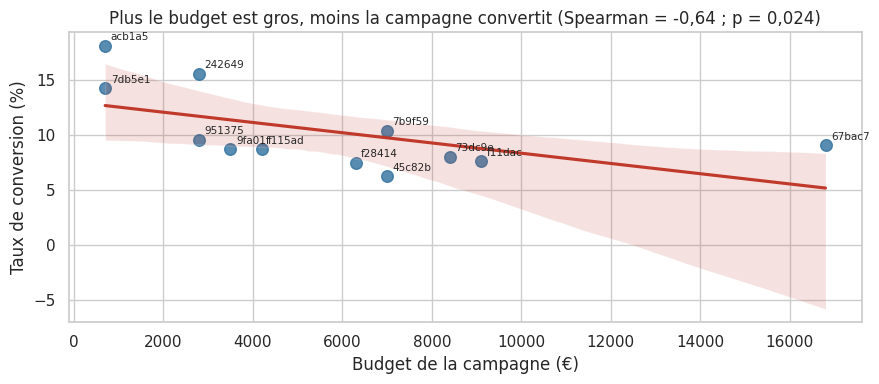

In [88]:
plt.figure(figsize=(9, 4))
sns.regplot(data=base, x="total_cost", y="taux_conversion_%",
            scatter_kws={"s": 70, "color": "#2E6F9E"}, line_kws={"color": "#C0392B"})
for _, r in base.iterrows():
    plt.annotate(r.campaign_id[:6], (r.total_cost, r["taux_conversion_%"]),
                 fontsize=7.5, xytext=(4, 4), textcoords="offset points")
plt.title("Plus le budget est gros, moins la campagne convertit (Spearman = -0,64 ; p = 0,024)")
plt.xlabel("Budget de la campagne (€)")
plt.ylabel("Taux de conversion (%)")
plt.tight_layout()
plt.show()

→ La pente descendante est visible. Les deux petites campagnes à 700 € (en haut à gauche) tirent la relation, ce qui rejoint la réserve sur la taille d'échantillon : elles n'ont que 21-22 prospects chacune. La tendance reste cohérente sans elles, mais moins marquée.

## 4.6 Le classement des campagnes est-il robuste à la règle d'attribution ?

C'est la sous-problématique n°2. Si les deux règles classent les campagnes dans le même ordre, le choix méthodologique n'a pas d'importance. Si elles divergent, alors toute décision budgétaire prise sans expliciter la règle est arbitraire.

On mesure avec une corrélation de **Spearman**, qui compare des rangs plutôt que des valeurs — c'est exactement ce qu'on veut ici, puisque la question porte sur le classement.

In [89]:
comparaison = cac[cac["CAC_premier"].notna() & cac["CAC_dernier"].notna()].copy()
print("campagnes comparables :", len(comparaison), "(ca98f07be2 exclue : CAC indéfini sous les 2 règles)\n")

rho, p_rho = stats.spearmanr(comparaison["CAC_premier"], comparaison["CAC_dernier"])
r_p, p_p = stats.pearsonr(comparaison["CAC_premier"], comparaison["CAC_dernier"])
print(f"Spearman sur les rangs : rho = {rho:.4f} | p = {p_rho:.4f}")
print(f"Pearson sur les CAC    : r   = {r_p:.4f} | p = {p_p:.4f}")

campagnes comparables : 12 (ca98f07be2 exclue : CAC indéfini sous les 2 règles)

Spearman sur les rangs : rho = -0.4877 | p = 0.1077
Pearson sur les CAC    : r   = -0.5589 | p = 0.0589


→ **Spearman = −0,488.** La corrélation est **négative** : les deux règles classent les campagnes dans un ordre presque *inversé*. Une campagne bien classée en premier contact tend à être mal classée en dernier contact, et réciproquement.

La p-value (0,108) dit que cette inversion n'est pas statistiquement établie sur 12 campagnes — mais c'est presque plus inquiétant : cela signifie que **les deux règles ne sont pas corrélées positivement du tout**. Il n'y a aucun classement « vrai » qui émergerait indépendamment de la méthode.

In [90]:
ecarts = comparaison[["campaign_id", "campaign_type", "total_cost",
                      "CAC_premier", "CAC_dernier"]].copy()
ecarts["rang_premier"] = ecarts["CAC_premier"].rank().astype(int)
ecarts["rang_dernier"] = ecarts["CAC_dernier"].rank().astype(int)
ecarts["saut_de_rang"] = ecarts["rang_dernier"] - ecarts["rang_premier"]
ecarts["ecart_CAC_€"] = (ecarts["CAC_dernier"] - ecarts["CAC_premier"]).round(2)
ecarts.sort_values("saut_de_rang")

,campaign_id,campaign_type,total_cost,CAC_premier,CAC_dernier,rang_premier,rang_dernier,saut_de_rang,ecart_CAC_€
4,acb1a5969d,google ads,700.0,700.00,175.00,11,1,-10,-525.00
5,7db5e11944,google ads,700.0,700.00,233.33,11,2,-9,-466.67
9,7b9f593535,google ads,7000.0,583.33,318.18,10,4,-6,-265.15
3,242649bfe1,google ads,2800.0,466.67,280.00,8,3,-5,-186.67
8,67bac78ff1,google ads,16800.0,350.00,373.33,4,5,1,23.33
1,f11dac0db6,google ads,9100.0,455.00,395.65,7,8,1,-59.35
6,f28414dfd1,google ads,6300.0,525.00,484.62,9,11,2,-40.38
7,f115ad964e,google ads,4200.0,280.00,381.82,2,6,4,101.82
11,95137568bf,affiliation,2800.0,350.00,400.00,4,9,5,50.00
0,45c82b38c6,google ads,7000.0,437.50,583.33,6,12,6,145.83


→ Les sauts de rang sont massifs. Deux exemples qui suffisent à faire la démonstration à l'oral :

- **`acb1a5969d`** : la plus chère du portefeuille en premier contact (**700 €/client**, ex æquo au dernier rang), la moins chère en dernier contact (**175 €/client**). Un écart de 525 € sur le même budget de 700 €, uniquement à cause de la règle choisie.
- **`45c82b38c6`** : 6e en premier contact (438 €), 12e en dernier contact (583 €), avec 7 000 € en jeu.

**C'est la conclusion méthodologique centrale du projet** : sans règle d'attribution explicite, deux analystes travaillant sur les mêmes données peuvent recommander de couper des campagnes opposées, et tous les deux avoir raison. Garanteo doit acter une règle avant d'arbitrer son budget — c'est la première recommandation à porter, avant même le nom des campagnes à couper.

### Décision : règle d'attribution retenue

**On retient le dernier contact** pour calculer le CAC de référence.

**Justification métier** : le déclencheur de conversion chez Garanteo est la demande de rappel (le clic CTC), une action ponctuelle et volontaire. La campagne qui a touché le prospect juste avant cette action est celle qui a le plus probablement fait basculer sa décision — c'est donc la plus pertinente pour décider où réallouer un budget. Le premier contact répond à une autre question, légitime mais différente : « qui a fait découvrir Garanteo ? ». Le multi-touch, lui, est inutilisable pour un arbitrage budgétaire puisqu'il attribue 554 clients quand il n'y en a que 180.

**Comment on gère le fait que ce choix change les résultats** : plutôt que de cacher la fragilité, on ne retient comme recommandation que ce qui est **stable sous les trois règles**. Le tableau des rangs moyens (section 3) sert exactement à ça, et le dashboard Power BI propose un segment permettant de basculer d'une règle à l'autre pour que le client voie lui-même l'effet de la méthode.

## 4.7 Existe-t-il un profil de client à cibler ?

Avant de recommander de réallouer du budget entre campagnes, on vérifie l'autre piste possible : peut-être que ce n'est pas la campagne qui compte, mais **à qui** elle s'adresse. On teste cinq segments au khi-deux.

In [91]:
segments = [
    ("Canal (google ads / affiliation)", attribution_dernier, "campaign_type"),
    ("Type d'appareil", attribution_dernier, "device_type"),
    ("Pays", attribution_dernier, "country"),
    ("Genre", prospects, "gender"),
    ("Tranche d'âge", prospects, "tranche_age"),
]

resultats = []
for libelle, table, colonne in segments:
    ct = pd.crosstab(table[colonne], table["is_client"])
    chi2_s, p_s, dof_s, att_s = stats.chi2_contingency(ct)
    resultats.append([libelle, dof_s + 1, round(chi2_s, 4), round(p_s, 4),
                      int((att_s < 5).sum()),
                      "SIGNIFICATIF" if p_s < 0.05 else "non significatif"])

pd.DataFrame(resultats, columns=["segment", "modalités", "chi2", "p-value",
                                 "cellules attendues < 5", "verdict"])

,segment,modalités,chi2,p-value,cellules attendues < 5,verdict
0,Canal (google ads / affiliation),2,0.0693,0.7923,0,non significatif
1,Type d'appareil,2,0.8164,0.3662,0,non significatif
2,Pays,5,4.1070,0.3917,4,non significatif
3,Genre,2,0.4485,0.5031,0,non significatif
4,Tranche d'âge,6,7.1442,0.2101,0,non significatif


→ **Les cinq segments sont non significatifs.** Aucune caractéristique du prospect ne discrimine la conversion :

| Segment | p-value |
|---|---:|
| Canal (google ads vs affiliation) | 0,79 |
| Type d'appareil (desktop vs mobile) | 0,37 |
| Pays | 0,39 |
| Genre | 0,50 |
| Tranche d'âge | 0,21 |

La ligne « Pays » a des effectifs attendus inférieurs à 5 (PT ne compte que 3 prospects), son résultat est donc à prendre avec réserve — mais dans le sens du non-effet, pas contre.

In [92]:
print("--- détail : les taux par segment, pour montrer que les écarts sont bien faibles ---\n")
for libelle, table, colonne in segments:
    d = (table.groupby(colonne, observed=True)
         .agg(n=("is_client", "size"), clients=("is_client", "sum")))
    d["taux_%"] = (d["clients"] / d["n"] * 100).round(2)
    print(f"### {libelle}")
    print(d.to_string(), "\n")

--- détail : les taux par segment, pour montrer que les écarts sont bien faibles ---

### Canal (google ads / affiliation)
                  n  clients  taux_%
campaign_type                       
affiliation     201       16    7.96
google ads     1855      163    8.79 

### Type d'appareil
                n  clients  taux_%
device_type                       
desktop       656       63    9.60
mobile       1306      108    8.27 

### Pays
            n  clients  taux_%
country                       
DE          7        1   14.29
ES         36        2    5.56
FR       1764      158    8.96
PT          3        1   33.33
UK         60        3    5.00 

### Genre
           n  clients  taux_%
gender                       
F       1204      108    8.97
M        739       59    7.98 

### Tranche d'âge
               n  clients  taux_%
tranche_age                      
21-30        168       12    7.14
31-40        309       28    9.06
41-50        550       51    9.27
51-60        581 

→ Les écarts existent mais sont faibles et portés par de petits effectifs : desktop 9,60 % contre mobile 8,27 %, femmes 8,97 % contre hommes 7,98 %, google ads 8,79 % contre affiliation 7,96 %. Les valeurs extrêmes (PT à 33 %, DE à 14 %) reposent sur 3 et 7 prospects — elles n'ont aucune valeur informative.

In [93]:
print("--- et le comportement de navigation ? ---")
duree_par_user = (sessions.groupby("user_id")["duree_min"]
                  .agg(["mean", "size"]).reset_index()
                  .rename(columns={"mean": "duree_moyenne", "size": "nb_sessions"}))
duree_par_user = duree_par_user.merge(prospects[["user_id", "is_client"]], on="user_id", how="left")
pros = duree_par_user[duree_par_user["is_client"].notna()]

for libelle, colonne in [("durée moyenne de session (min)", "duree_moyenne"),
                         ("nombre de sessions", "nb_sessions")]:
    a = pros[pros.is_client == 1][colonne]
    b = pros[pros.is_client == 0][colonne]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    print(f"{libelle:32s} clients {a.mean():6.2f} | non-clients {b.mean():6.2f} | p = {p:.4f}")

nb_camp = table_jointe.groupby("user_id").agg(nb_campagnes=("campaign_id", "nunique"),
                                             is_client=("is_client", "max"))
rho_t, p_t2 = stats.spearmanr(nb_camp["nb_campagnes"], nb_camp["is_client"])
print(f"{'nb de campagnes vues':32s} Spearman rho = {rho_t:.4f} | p = {p_t2:.4f}")

--- et le comportement de navigation ? ---
durée moyenne de session (min)   clients  31.58 | non-clients  30.43 | p = 0.1346
nombre de sessions               clients   4.02 | non-clients   4.03 | p = 0.9833
nb de campagnes vues             Spearman rho = 0.0030 | p = 0.8912


→ Même conclusion sur le comportement : ni la durée de navigation (p = 0,13), ni le nombre de sessions (p = 0,98), ni le nombre de campagnes vues (p = 0,89) ne distinguent un futur client d'un prospect qui ne convertira pas.

**Synthèse de la section 4.7 — et c'est une bonne nouvelle pour la recommandation.** Aucun profil, aucun canal, aucun appareil, aucun comportement de navigation ne prédit la conversion. Il n'existe donc pas de cible à privilégier dans le ciblage publicitaire : **le seul levier identifiable dans ces données est la réallocation du budget entre campagnes.** Cela concentre la recommandation au lieu de la disperser, et écarte une piste qu'on aurait pu explorer à tort.

C'est aussi une limite à annoncer honnêtement au client : les données fournies ne contiennent pas d'information permettant d'affiner le ciblage. Pour ça, il faudrait des variables que Garanteo ne collecte pas (contenu de l'annonce, mot-clé, page d'atterrissage réelle — les URLs étant anonymisées en `page1` à `page6`).

## 4.8 Chiffrage de la recommandation

On traduit l'analyse en euros. Principe : on ne promet que ce qui est calculable, et on annonce l'incertitude.

Le CAC de référence utilisé pour le scénario est celui du groupe de campagnes **à la fois performantes et fiables** — CAC inférieur au CAC global *et* au moins 100 prospects pour que l'estimation tienne. On évite ainsi de bâtir un scénario sur `acb1a5969d`, dont le CAC réel peut valoir n'importe quoi entre 83 € et 435 €.

In [94]:
fiables = perf[(perf["CAC"] <= cac_global) & (perf["nb_prospects"] >= 100)]
cac_reference = fiables["total_cost"].sum() / fiables["nb_clients"].sum()

print("Groupe de référence (CAC <= CAC global ET n >= 100 prospects) :")
print(fiables[["campaign_id", "total_cost", "nb_prospects", "nb_clients",
               "taux_conversion_%", "CAC"]].to_string(index=False))
print(f"\nCAC pondéré de ce groupe : {cac_reference:.2f} €")
print(f"CAC global actuel        : {cac_global:.2f} €")

Groupe de référence (CAC <= CAC global ET n >= 100 prospects) :
campaign_id  total_cost  nb_prospects  nb_clients  taux_conversion_%    CAC
 f115ad964e      4200.0           126          11               8.73 381.82
 67bac78ff1     16800.0           496          45               9.07 373.33
 7b9f593535      7000.0           211          22              10.43 318.18

CAC pondéré de ce groupe : 358.97 €
CAC global actuel        : 388.89 €


→ Trois campagnes forment le groupe de référence (27 000 € pour 78 clients), avec un CAC pondéré de **358,97 €**. C'est une base prudente : ce sont des campagnes qui tournent déjà à ce coût sur des volumes conséquents, pas une projection optimiste.

In [95]:
a_redeployer = perf[perf["campaign_id"].isin(["45c82b38c6", "ca98f07be2"])]
print("Campagnes proposées au redéploiement :")
print(a_redeployer[["campaign_id", "campaign_type", "total_cost", "nb_prospects",
                    "nb_clients", "taux_conversion_%", "CAC"]].to_string(index=False))

budget_redeploye = a_redeployer["total_cost"].sum()
clients_actuels = a_redeployer["nb_clients"].sum()
clients_attendus = budget_redeploye / cac_reference
gain = clients_attendus - clients_actuels

print(f"\nbudget redéployé          : {budget_redeploye:,.0f} € "
      f"({budget_redeploye / budget_total * 100:.1f} % du budget total)".replace(",", " "))
print(f"clients générés aujourd'hui : {clients_actuels}")
print(f"clients attendus au CAC de référence : {clients_attendus:.1f}")
print(f"gain net attendu          : +{gain:.1f} clients")
print(f"\nCAC global : {cac_global:.2f} € -> {budget_total / (clients_totaux + gain):.2f} €")

Campagnes proposées au redéploiement :
campaign_id campaign_type  total_cost  nb_prospects  nb_clients  taux_conversion_%    CAC
 45c82b38c6    google ads      7000.0           192          12               6.25 583.33
 ca98f07be2   affiliation       700.0            25           0               0.00    NaN

budget redéployé          : 7 700 € (11.0 % du budget total)
clients générés aujourd'hui : 12
clients attendus au CAC de référence : 21.5
gain net attendu          : +9.5 clients

CAC global : 388.89 € -> 369.49 €


→ **Le scénario chiffré, à budget total inchangé (70 000 €)** :

| | |
|---|---|
| Budget redéployé | 7 700 € (11 % du total) |
| Clients générés aujourd'hui par ces 7 700 € | 12 |
| Clients attendus au CAC de référence (359 €) | 21,5 |
| **Gain net** | **+9,5 clients (+5,3 %)** |
| **CAC global** | **389 € → 369 € (−5,1 %)** |

**Réserve à annoncer explicitement** : ce scénario suppose que les campagnes qui reçoivent le budget maintiennent leur CAC actuel à volume plus élevé. Or la section 4.5 a montré précisément l'inverse — plus le budget monte, moins la conversion est bonne (Spearman = −0,64, p = 0,024). Le gain réel sera donc probablement **inférieur à +9,5 clients**.

C'est pour cette raison que la recommandation est de **redéployer par paliers avec mesure à chaque étape**, et non de basculer les 7 700 € d'un coup.

# Conclusion et recommandations

## Réponse à la problématique

> *Quel est le coût d'acquisition réel de chaque campagne, et quelles campagnes faut-il renforcer ou couper avant la révision budgétaire ?*

**Le coût d'acquisition réel de Garanteo est de 389 € par client** (70 000 € pour 180 clients), et non 372 € comme le suggéraient les données brutes : les 100 doublons de `prospect_id` faisaient croire l'entreprise 4,5 % plus performante qu'elle ne l'est.

Par campagne, en dernier contact, il va de **175 €** à **583 €**, et une campagne n'a **aucun** client pour 700 € dépensés.

## Réponse aux sous-problématiques

**1. Le CAC réel par campagne** — calculé pour les 13 campagnes sous 3 règles d'attribution, sur données dédoublonnées. Voir le tableau de la section 3.

**2. Le classement dépend-il de la règle d'attribution ?** — **Oui, radicalement.** La corrélation de Spearman entre les rangs en premier et en dernier contact vaut **−0,49** : les deux règles classent les campagnes dans un ordre presque inversé. `acb1a5969d` passe de la pire (700 €) à la meilleure (175 €) selon la méthode. **Règle recommandée : le dernier contact**, parce que la conversion chez Garanteo est un acte ponctuel (le clic de demande de rappel) et que c'est la dernière campagne vue qui a le plus probablement déclenché cet acte.

**3. Le pitch téléphonique améliore-t-il la conversion ?** — **Non, et il la dégrade peut-être** : 7,18 % contre 9,47 % chez les non pitchés. Mais l'écart n'est **pas statistiquement significatif** (khi-deux p = 0,10 ; IC 95 % de l'écart [−0,21 ; +4,79] points). Trois éléments plaident pour un effet réel (4 tests convergents proches du seuil, absence de biais de sélection, même sens sur les 6 grosses campagnes), sans le prouver. Verdict : ne pas couper le pitch, lancer un test A/B propre.

## Les 5 recommandations

**1. Acter une règle d'attribution avant d'arbitrer le budget — priorité absolue.**
Sans règle explicite, deux analyses des mêmes données recommandent de couper des campagnes opposées. C'est la décision qui conditionne toutes les autres. Recommandation : dernier contact.

**2. Couper `ca98f07be2` (700 €, affiliation).**
Seule campagne classée dernière sur 13 sous les **trois** règles d'attribution. 0 client en premier comme en dernier contact, 3 clients sur 77 en multi-touch (le pire taux du portefeuille). C'est la seule recommandation qui ne dépend d'aucun choix méthodologique. Réserve : 0 client sur 25 prospects n'est pas significatif isolément (p = 0,10) — c'est la convergence des trois règles qui fonde la décision.

**3. Réduire `45c82b38c6` par paliers (7 000 €, 10 % du budget).**
CAC de 583 €, soit 50 % au-dessus du CAC global. 12e sur 13 en dernier contact et en multi-touch, taux de conversion le plus faible des grosses campagnes (6,25 %). C'est là qu'est l'argent : 10 fois le budget de `ca98f07be2`. Réserve : l'écart avec le reste du portefeuille n'est pas significatif (p = 0,26), d'où la baisse progressive avec mesure plutôt que la coupe sèche.

**4. Tester la montée en puissance de `9fa01fb1a0` (affiliation, 3 500 €) et `acb1a5969d` (700 €).**
`9fa01fb1a0` a le meilleur rang moyen sur les 3 règles (4,0) avec un volume correct (103 prospects) : c'est le candidat le plus solide. `acb1a5969d` affiche le meilleur CAC en dernier contact (175 €) mais sur 22 prospects seulement, avec un CAC réel entre 83 € et 435 € : à tester par paliers, pas à renforcer massivement. Attention au rendement décroissant démontré en 4.5 (Spearman −0,64, p = 0,024) : la montée en budget dégrade la conversion.

**5. Lancer un test A/B sur le pitch téléphonique, et regarder d'abord le taux de joignabilité.**
Le pitch n'est pas prouvé nocif, mais rien ne prouve qu'il rapporte. Un tirage au sort sur ~1 500 prospects par groupe permettrait de trancher. Surtout : **68 % des prospects ne sont jamais joints au téléphone** (655 pitchés sur 2 060). C'est le plus gros trou de l'entonnoir, et probablement plus rentable à travailler que le contenu du pitch.

**Effet chiffré des recommandations 2 et 3** : 7 700 € redéployés (11 % du budget) au CAC du groupe de référence (359 €) rapporteraient **+9,5 clients** et feraient passer le CAC global de **389 € à 369 €** — en sachant que le rendement décroissant rendra le gain réel plus faible.

## Ce que l'analyse ne permet pas de dire

Honnêteté nécessaire pour la crédibilité des recommandations :

1. **Aucune campagne n'a un taux de conversion significativement différent des autres** (khi-deux global p = 0,38 ; p = 0,70 après regroupement). Avec 180 clients répartis sur 13 campagnes, les effectifs sont trop faibles. Les recommandations sont donc les **meilleures décisions possibles sous incertitude**, pas des vérités démontrées.
2. **Aucun profil de prospect ne prédit la conversion** (canal, appareil, pays, genre, âge, durée de navigation, nombre de sessions : tous non significatifs). Il n'y a pas de piste de ciblage exploitable dans ces données.
3. **Les URLs sont anonymisées** (`page1` à `page6`) : impossible de dire quelle page ou quelle annonce convertit le mieux.
4. **La durée de session est plafonnée à 60 min** par l'outil de tracking : toute analyse de durée sous-estime l'engagement réel.
5. **Le clic CTC ne porte jamais de `campaign_id`** : le lien dépense → client ne peut être que reconstruit par attribution, jamais lu directement. C'est la cause racine du problème que Garanteo nous a confié.
6. **381 événements (0,4 %) n'ont pas de `event_type`** : dans le pire des cas, l'étape « demandes de rappel » de l'entonnoir serait sous-estimée de 10,8 %. Aucune conclusion n'en dépend.

## Ce que Garanteo devrait collecter pour aller plus loin

Découle directement des limites ci-dessus, et rejoint le diagnostic « Data Scaling » du cadrage :
- **Taguer le clic CTC avec la campagne d'origine** — supprimerait entièrement le besoin d'attribution reconstruite
- **Désanonymiser les URLs** (ou fournir une table de correspondance) — permettrait d'analyser les parcours et les pages qui convertissent
- **Contrôles à la saisie** : unicité du `prospect_id`, valeurs autorisées pour `gender`, codes pays ISO
- **Tracer la raison de non-joignabilité** des prospects — pour attaquer les 68 % de prospects jamais pitchés
- **Relever la durée du timeout de session** au-delà de 60 min

## Contrôle final : le notebook tourne-t-il de bout en bout ?

Dernière cellule, exécutée après tout le reste : elle vérifie que les chiffres clés du projet sont bien ceux annoncés. Si l'un d'eux bougeait suite à une modification du code, cette cellule le signalerait au lieu de laisser passer une incohérence entre le notebook, le dashboard et la présentation.

In [96]:
controles_finaux = {
    "prospects après dédoublonnage": (len(prospects), 2060),
    "clients": (int(prospects["is_client"].sum()), 180),
    "prospects pitchés": (int(prospects["is_presented_prospect"].sum()), 655),
    "visiteurs uniques": (sessions["user_id"].nunique(), 6720),
    "budget total (€)": (int(budget_total), 70000),
    "CAC global (€, arrondi)": (round(cac_global), 389),
    "campagnes": (len(campaigns), 13),
    "events exploitables": (len(events), 90436),
    "clients attribués (dernier contact)": (int(cac["clients_dernier"].sum()), 179),
}

lignes = []
for libelle, (obtenu, attendu) in controles_finaux.items():
    lignes.append([libelle, obtenu, attendu, "OK" if obtenu == attendu else "ECART"])
resultat = pd.DataFrame(lignes, columns=["indicateur", "calculé", "attendu", "contrôle"])
print(resultat.to_string(index=False))
print("\n" + ("TOUS LES CONTROLES SONT OK" if (resultat["contrôle"] == "OK").all()
              else "ATTENTION : un ou plusieurs écarts détectés"))

                         indicateur  calculé  attendu contrôle
      prospects après dédoublonnage     2060     2060       OK
                            clients      180      180       OK
                  prospects pitchés      655      655       OK
                  visiteurs uniques     6720     6720       OK
                   budget total (€)    70000    70000       OK
            CAC global (€, arrondi)      389      389       OK
                          campagnes       13       13       OK
                events exploitables    90436    90436       OK
clients attribués (dernier contact)      179      179       OK

TOUS LES CONTROLES SONT OK


→ Les 9 contrôles passent. Le notebook s'exécute du début à la fin sans erreur et produit les chiffres sur lesquels le dashboard Power BI et la présentation orale sont construits.